In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, glob
from scipy import stats
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
print("Libraries loaded.")

Libraries loaded.


In [3]:
transfer_files = [
    'premier-league.csv', 'serie-a.csv', '1-bundesliga.csv', 'primera-division.csv',
    'ligue-1.csv', 'championship.csv', 'eredivisie.csv', 'liga-nos.csv', 'premier-liga.csv'
]

dfs = []
for f in transfer_files:
    temp = pd.read_csv(f)
    dfs.append(temp)
    print(f"  {f:25s}: {temp.shape[0]:>6,} records | {temp['league_name'].iloc[0]}")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {df_raw.shape[0]:,} transfer records across {df_raw['league_name'].nunique()} leagues")
print(f"Years: {df_raw['year'].min()}–{df_raw['year'].max()}")

  premier-league.csv       : 23,675 records | Premier League
  serie-a.csv              : 28,433 records | Serie A
  1-bundesliga.csv         : 14,158 records | 1 Bundesliga
  primera-division.csv     : 17,380 records | Primera Division
  ligue-1.csv              : 17,580 records | Ligue 1
  championship.csv         : 24,241 records | Championship
  eredivisie.csv           : 15,264 records | Eredivisie
  liga-nos.csv             : 21,734 records | Liga Nos
  premier-liga.csv         : 14,947 records | Premier Liga

Total: 177,412 transfer records across 9 leagues
Years: 1992–2022


In [18]:
# FIFA game year → real-world transfer year mapping
# FIFA 22 released Sep 2021, reflects 2021/22 season
fifa_year_map = {15:2014, 16:2015, 17:2016, 18:2017, 19:2018, 20:2019, 21:2020, 22:2021}

fifa_keep_cols = ['short_name','long_name','club_name','league_name','overall','potential',
                  'international_reputation','wage_eur','age','pace','shooting','passing',
                  'dribbling','defending','physic','skill_moves','weak_foot']

all_fifa = []
for yr in range(15, 23):
    path = f'players_{yr}.csv'
    if os.path.exists(path):
        f_df = pd.read_csv(path, usecols=[c for c in fifa_keep_cols if c in
                pd.read_csv(path, nrows=0).columns], low_memory=False)
        f_df['fifa_year'] = yr
        f_df['transfer_year'] = fifa_year_map.get(yr, 2000 + yr - 1)
        all_fifa.append(f_df)
        print(f"  FIFA {yr}: {len(f_df):>6,} players → transfer year {f_df['transfer_year'].iloc[0]}")

fifa_all = pd.concat(all_fifa, ignore_index=True)
print(f"\nTotal FIFA records: {len(fifa_all):,} across {len(all_fifa)} editions")
print(f"\nSample (FIFA 22):")
print(fifa_all[fifa_all['fifa_year']==22][['short_name','club_name','overall','potential','pace']].head())

  FIFA 15: 16,155 players → transfer year 2014
  FIFA 16: 15,623 players → transfer year 2015
  FIFA 17: 17,596 players → transfer year 2016
  FIFA 18: 17,954 players → transfer year 2017
  FIFA 19: 18,085 players → transfer year 2018
  FIFA 20: 18,483 players → transfer year 2019
  FIFA 21: 18,944 players → transfer year 2020
  FIFA 22: 19,239 players → transfer year 2021

Total FIFA records: 142,079 across 8 editions

Sample (FIFA 22):
               short_name            club_name  overall  potential  pace
122840           L. Messi  Paris Saint-Germain       93         93  85.0
122841     R. Lewandowski    FC Bayern München       92         92  78.0
122842  Cristiano Ronaldo    Manchester United       91         91  87.0
122843          Neymar Jr  Paris Saint-Germain       91         91  91.0
122844       K. De Bruyne      Manchester City       91         91  76.0


2.Data Cleaning

In [19]:
# Understand the raw data
print("=== Fee Column Breakdown ===")
print(f"  Paid (fee > 0):    {(df_raw['fee_cleaned'] > 0).sum():>7,}")
print(f"  Free (fee == 0):   {(df_raw['fee_cleaned'] == 0).sum():>7,}")
print(f"  Unknown/Loan (NaN):{df_raw['fee_cleaned'].isna().sum():>7,}")
print(f"\nNaN fee breakdown:")
print(df_raw[df_raw['fee_cleaned'].isna()]['fee'].value_counts().head(6))
print(f"\nDuplicates: {df_raw.duplicated().sum()}")
print(f"Null ages: {df_raw['age'].isna().sum()}")

=== Fee Column Breakdown ===
  Paid (fee > 0):     32,969
  Free (fee == 0):    33,595
  Unknown/Loan (NaN):110,848

NaN fee breakdown:
fee
loan transfer              37508
?                          24251
-                          17321
End of loanJun 30, 2022     1021
End of loanJun 30, 2019     1013
End of loanJun 30, 2021     1001
Name: count, dtype: int64

Duplicates: 45
Null ages: 70


In [20]:
# Filter: incoming paid transfers
df = df_raw[(df_raw['transfer_movement'] == 'in') &
            (df_raw['fee_cleaned'].notna()) &
            (df_raw['fee_cleaned'] > 0)].copy()
print(f"After filtering (incoming, fee > 0): {len(df):,}")

# Standardise positions
pos_map = {'attack':'Centre-Forward', 'defence':'Centre-Back', 'midfield':'Central Midfield'}
df['position'] = df['position'].replace(pos_map)

pos_groups = {
    'Goalkeeper':'Goalkeeper',
    'Centre-Back':'Defender','Left-Back':'Defender','Right-Back':'Defender','Sweeper':'Defender',
    'Central Midfield':'Midfielder','Defensive Midfield':'Midfielder',
    'Attacking Midfield':'Midfielder','Left Midfield':'Midfielder','Right Midfield':'Midfielder',
    'Centre-Forward':'Forward','Second Striker':'Forward',
    'Left Winger':'Forward','Right Winger':'Forward'
}
df['position_group'] = df['position'].map(pos_groups)
df = df.dropna(subset=['position_group','age'])
df['age'] = df['age'].astype(int)
df['log_fee'] = np.log1p(df['fee_cleaned'])

print(f"Cleaned: {len(df):,} records")
print(f"\nBy league:\n{df['league_name'].value_counts().to_string()}")
print(f"\nBy position group:\n{df['position_group'].value_counts().to_string()}")

After filtering (incoming, fee > 0): 18,727
Cleaned: 18,723 records

By league:
league_name
Serie A             3600
Premier League      3421
1 Bundesliga        2810
Primera Division    2238
Ligue 1             1825
Championship        1646
Premier Liga        1413
Eredivisie           952
Liga Nos             818

By position group:
position_group
Forward       6448
Defender      5655
Midfielder    5527
Goalkeeper    1093


Exploratory Data Analysis


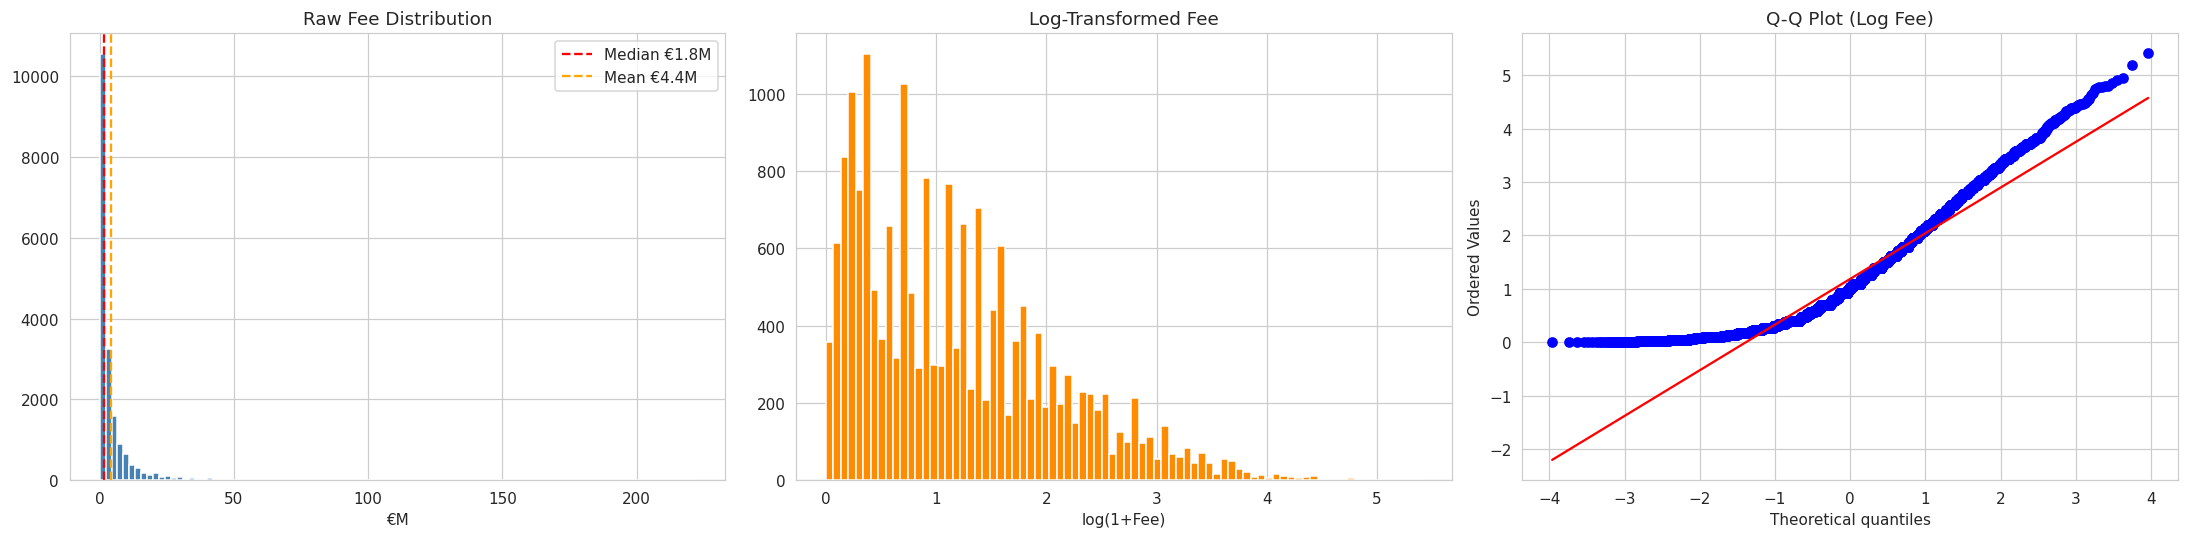

Raw — Skew: 6.47 | Kurtosis: 78.67
Log — Skew: 0.90 | Kurtosis: 0.34


In [21]:
#3.1 Target Variable
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(df['fee_cleaned'], bins=100, color='steelblue', edgecolor='white')
axes[0].axvline(df['fee_cleaned'].median(), color='red', ls='--', label=f"Median €{df['fee_cleaned'].median():.1f}M")
axes[0].axvline(df['fee_cleaned'].mean(), color='orange', ls='--', label=f"Mean €{df['fee_cleaned'].mean():.1f}M")
axes[0].set_title('Raw Fee Distribution'); axes[0].set_xlabel('€M'); axes[0].legend()

axes[1].hist(df['log_fee'], bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Transformed Fee'); axes[1].set_xlabel('log(1+Fee)')

stats.probplot(df['log_fee'], plot=axes[2])
axes[2].set_title('Q-Q Plot (Log Fee)')

plt.tight_layout(); plt.show()
print(f"Raw — Skew: {df['fee_cleaned'].skew():.2f} | Kurtosis: {df['fee_cleaned'].kurtosis():.2f}")
print(f"Log — Skew: {df['log_fee'].skew():.2f} | Kurtosis: {df['log_fee'].kurtosis():.2f}")

In [22]:
#3.2 Outlier Analysis
Q1, Q3 = df['fee_cleaned'].quantile(0.25), df['fee_cleaned'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: €{Q1:.2f}M | Q3: €{Q3:.2f}M | IQR: €{IQR:.2f}M")
print(f"Upper fence (1.5×IQR): €{Q3+1.5*IQR:.2f}M")
print(f"Outliers: {(df['fee_cleaned'] > Q3+1.5*IQR).sum():,} ({(df['fee_cleaned'] > Q3+1.5*IQR).mean()*100:.1f}%)")

print(f"\nTop 10 Transfers:")
for i, (_, r) in enumerate(df.nlargest(10, 'fee_cleaned').iterrows()):
    print(f"  {i+1:2d}. {r['player_name']:25s} → {r['club_name']:20s} €{r['fee_cleaned']:.0f}M ({r['year']})")
print("\n→ Outliers retained — log transform handles their influence.")

Q1: €0.52M | Q3: €4.50M | IQR: €3.98M
Upper fence (1.5×IQR): €10.47M
Outliers: 1,960 (10.5%)

Top 10 Transfers:
   1. Neymar                    → Paris Saint-Germain  €222M (2017)
   2. Kylian Mbappé             → Paris Saint-Germain  €180M (2018)
   3. Ousmane Dembélé           → FC Barcelona         €140M (2017)
   4. Philippe Coutinho         → FC Barcelona         €135M (2017)
   5. João Félix                → Atlético de Madrid   €127M (2019)
   6. Enzo Fernández            → Chelsea FC           €121M (2022)
   7. Antoine Griezmann         → FC Barcelona         €120M (2019)
   8. Jack Grealish             → Manchester City      €118M (2021)
   9. Cristiano Ronaldo         → Juventus FC          €117M (2018)
  10. Eden Hazard               → Real Madrid          €115M (2019)

→ Outliers retained — log transform handles their influence.


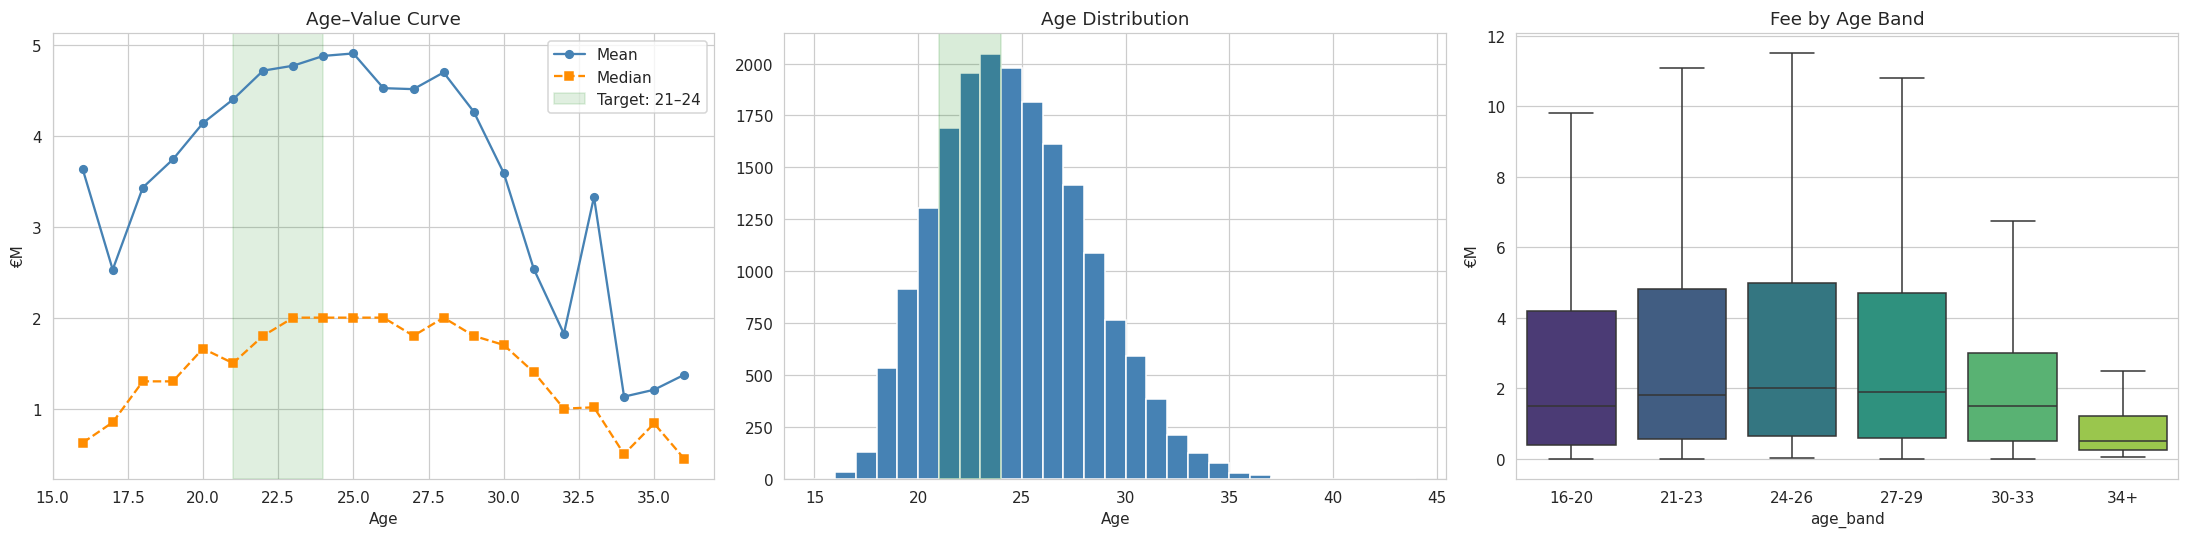

In [23]:
#3.3 Age–Value Curve

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

age_stats = df.groupby('age')['fee_cleaned'].agg(['mean','median','count']).reset_index()
age_stats = age_stats[age_stats['count'] >= 15]
axes[0].plot(age_stats['age'], age_stats['mean'], 'o-', color='steelblue', ms=5, label='Mean')
axes[0].plot(age_stats['age'], age_stats['median'], 's--', color='darkorange', ms=5, label='Median')
axes[0].axvspan(21, 24, alpha=0.12, color='green', label='Target: 21–24')
axes[0].set_title('Age–Value Curve'); axes[0].set_xlabel('Age'); axes[0].set_ylabel('€M'); axes[0].legend()

axes[1].hist(df['age'], bins=range(15,45), color='steelblue', edgecolor='white')
axes[1].axvspan(21, 24, alpha=0.15, color='green')
axes[1].set_title('Age Distribution'); axes[1].set_xlabel('Age')

df['age_band'] = pd.cut(df['age'], bins=[15,20,23,26,29,33,45], labels=['16-20','21-23','24-26','27-29','30-33','34+'])
sns.boxplot(data=df, x='age_band', y='fee_cleaned', palette='viridis', showfliers=False, ax=axes[2])
axes[2].set_title('Fee by Age Band'); axes[2].set_ylabel('€M')
plt.tight_layout(); plt.show()

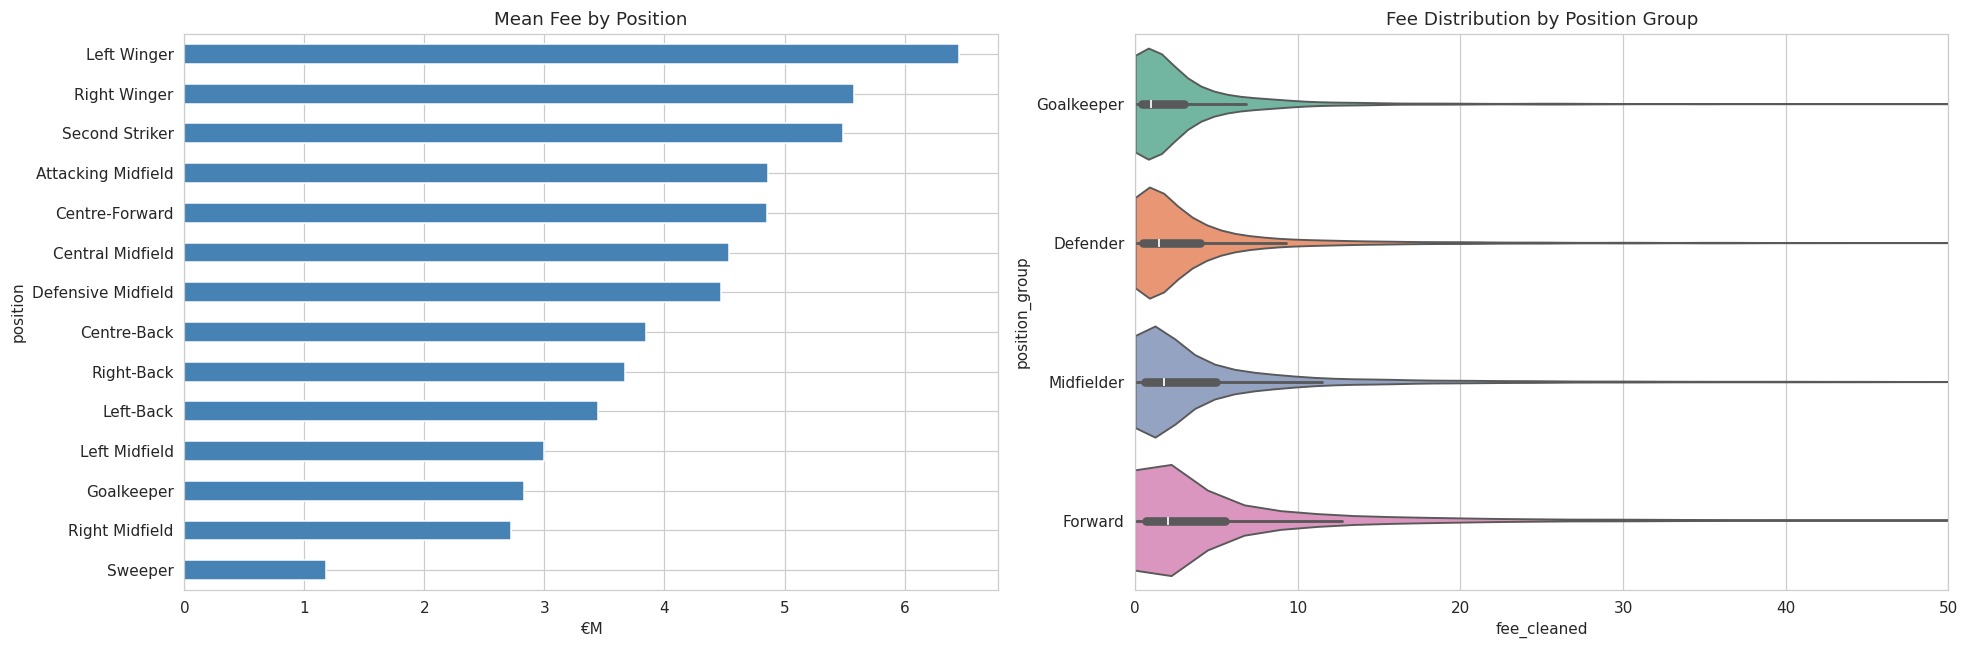

In [24]:
#3.4 Positional Analysis

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pos_stats = df.groupby('position')['fee_cleaned'].mean().sort_values()
pos_stats[pos_stats.index.isin(df['position'].value_counts()[df['position'].value_counts()>=20].index)].plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Mean Fee by Position'); axes[0].set_xlabel('€M')

sns.violinplot(data=df, y='position_group', x='fee_cleaned',
    order=df.groupby('position_group')['fee_cleaned'].mean().sort_values().index,
    palette='Set2', cut=0, ax=axes[1])
axes[1].set_title('Fee Distribution by Position Group'); axes[1].set_xlim(0, 50)
plt.tight_layout(); plt.show()

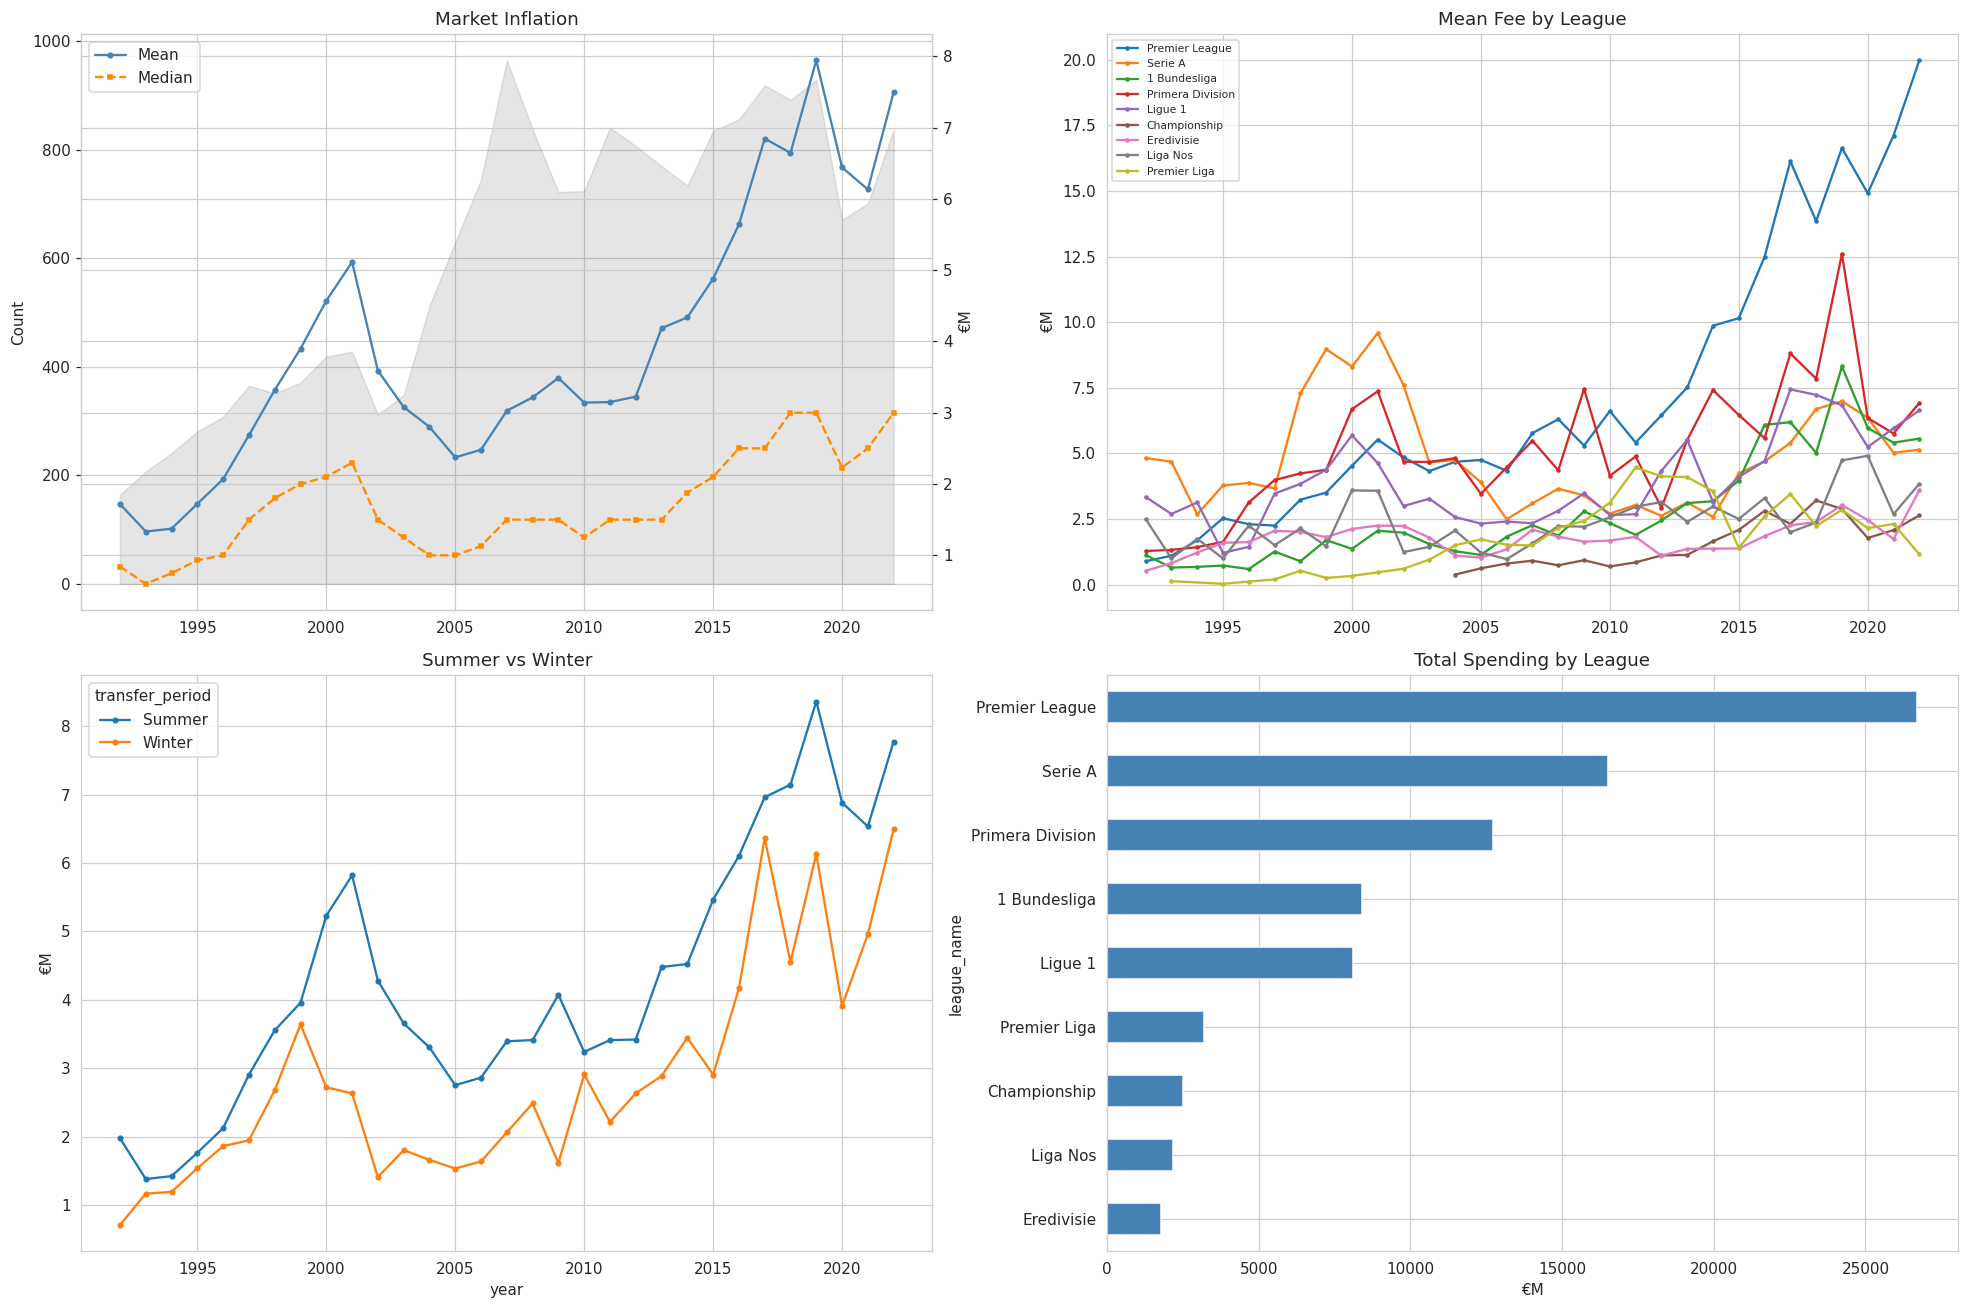

In [25]:
#3.5 Market Inflation & League Dynamics

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Inflation
yearly = df.groupby('year')['fee_cleaned'].agg(['mean','median','count']).reset_index()
axes[0,0].fill_between(yearly['year'], 0, yearly['count'], alpha=0.2, color='grey')
ax2 = axes[0,0].twinx()
ax2.plot(yearly['year'], yearly['mean'], 'o-', color='steelblue', ms=3, label='Mean')
ax2.plot(yearly['year'], yearly['median'], 's--', color='darkorange', ms=3, label='Median')
axes[0,0].set_title('Market Inflation'); ax2.legend(loc='upper left')
axes[0,0].set_ylabel('Count'); ax2.set_ylabel('€M')

# League over time
for lg in df['league_name'].unique():
    ly = df[df['league_name']==lg].groupby('year')['fee_cleaned'].mean()
    axes[0,1].plot(ly.index, ly.values, 'o-', ms=2, label=lg)
axes[0,1].set_title('Mean Fee by League'); axes[0,1].legend(fontsize=7); axes[0,1].set_ylabel('€M')

# Summer vs Winter
sw = df.groupby(['year','transfer_period'])['fee_cleaned'].mean().unstack()
sw.plot(ax=axes[1,0], marker='o', ms=3)
axes[1,0].set_title('Summer vs Winter'); axes[1,0].set_ylabel('€M')

# Total spend
df.groupby('league_name')['fee_cleaned'].sum().sort_values().plot.barh(ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Total Spending by League'); axes[1,1].set_xlabel('€M')
plt.tight_layout(); plt.show()

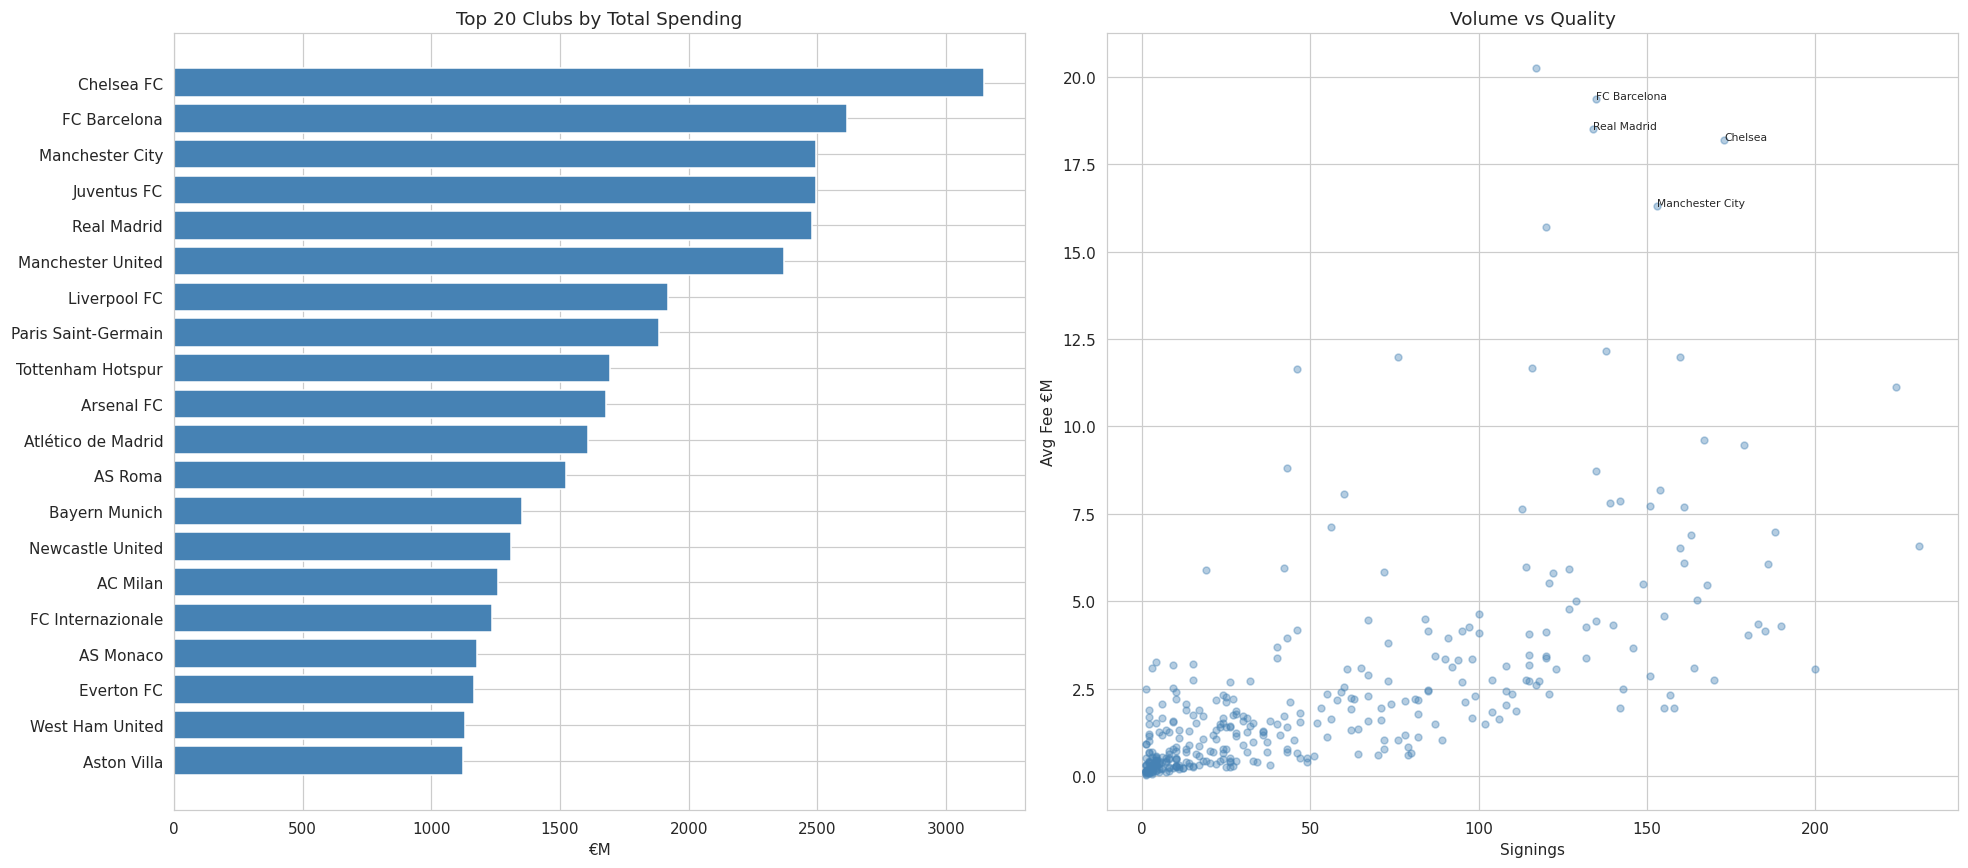

In [26]:
#3.6 Club Spending Patterns
club_stats = df.groupby('club_name').agg(
    signings=('fee_cleaned','count'), total=('fee_cleaned','sum'),
    avg=('fee_cleaned','mean'), max_fee=('fee_cleaned','max')
).sort_values('total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top20 = club_stats.head(20)
axes[0].barh(top20.index[::-1], top20['total'][::-1], color='steelblue')
axes[0].set_title('Top 20 Clubs by Total Spending'); axes[0].set_xlabel('€M')

axes[1].scatter(club_stats['signings'], club_stats['avg'], alpha=0.4, s=20, color='steelblue')
for c in ['Chelsea FC','FC Barcelona','Manchester City','Real Madrid','Paris SG']:
    if c in club_stats.index:
        r = club_stats.loc[c]
        axes[1].annotate(c.replace(' FC',''), (r['signings'], r['avg']), fontsize=7)
axes[1].set_xlabel('Signings'); axes[1].set_ylabel('Avg Fee €M'); axes[1].set_title('Volume vs Quality')
plt.tight_layout(); plt.show()

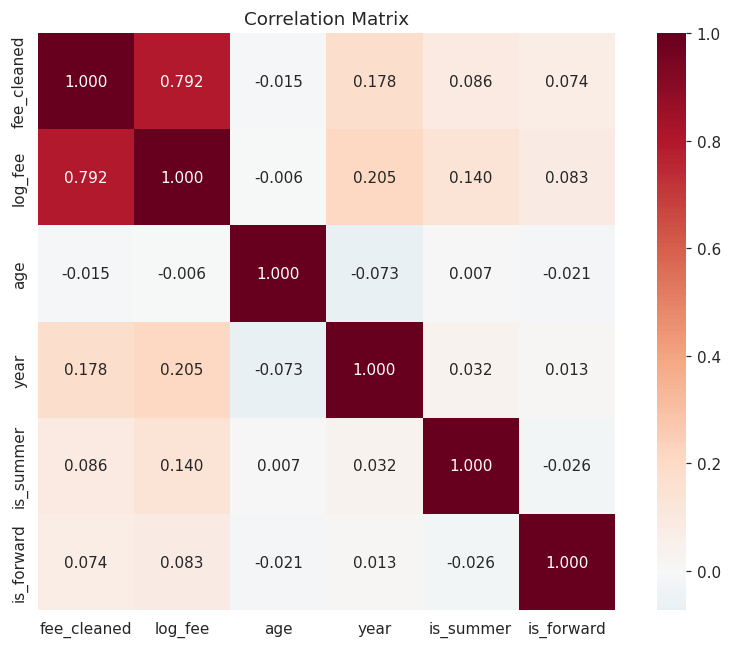

In [27]:
#3.7 Correlation Analysis
temp = df[['fee_cleaned','log_fee','age','year']].copy()
temp['is_summer'] = (df['transfer_period']=='Summer').astype(int)
temp['is_forward'] = (df['position_group']=='Forward').astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(temp.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.3f', square=True, ax=ax)
ax.set_title('Correlation Matrix'); plt.tight_layout(); plt.show()

4. Player Trial Decision Support


Recent (2018-2022): 4,030 | Young (21-24): 1,773

                     n    avg    med
league_name                        
Serie A           362   7.04   3.40
Premier League    252  20.22  15.63
Ligue 1           236   6.90   3.50
1 Bundesliga      215   6.60   3.20
Premier Liga      177   2.48   0.80
Primera Division  169   9.40   3.25
Championship      143   2.48   1.70
Liga Nos          114   3.88   1.40
Eredivisie        105   2.72   1.00


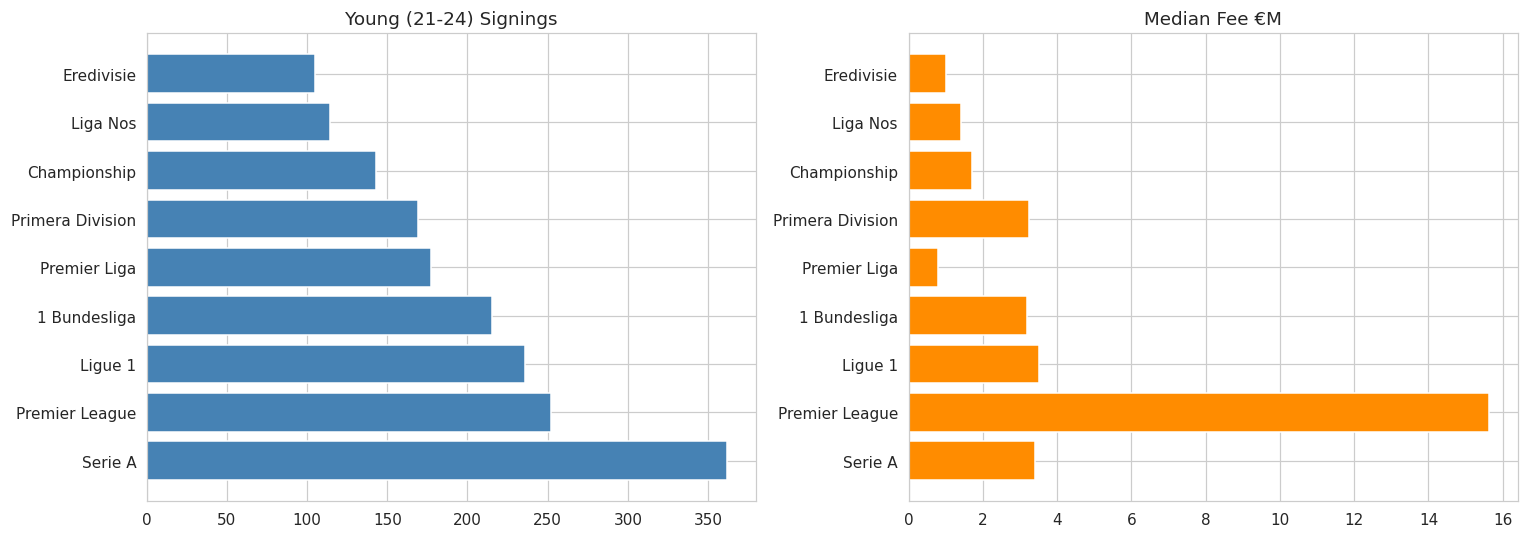

In [28]:
# 4.1 League Preferences for Young Players
recent = df[df['year'] >= 2018]
young = recent[(recent['age']>=21) & (recent['age']<=24)]
print(f"Recent (2018-2022): {len(recent):,} | Young (21-24): {len(young):,}")

ly = young.groupby('league_name').agg(n=('fee_cleaned','size'), avg=('fee_cleaned','mean'),
    med=('fee_cleaned','median')).round(2).sort_values('n', ascending=False)
print("\n", ly.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(ly.index, ly['n'], color='steelblue'); axes[0].set_title('Young (21-24) Signings')
axes[1].barh(ly.index, ly['med'], color='darkorange'); axes[1].set_title('Median Fee €M')
plt.tight_layout(); plt.show()

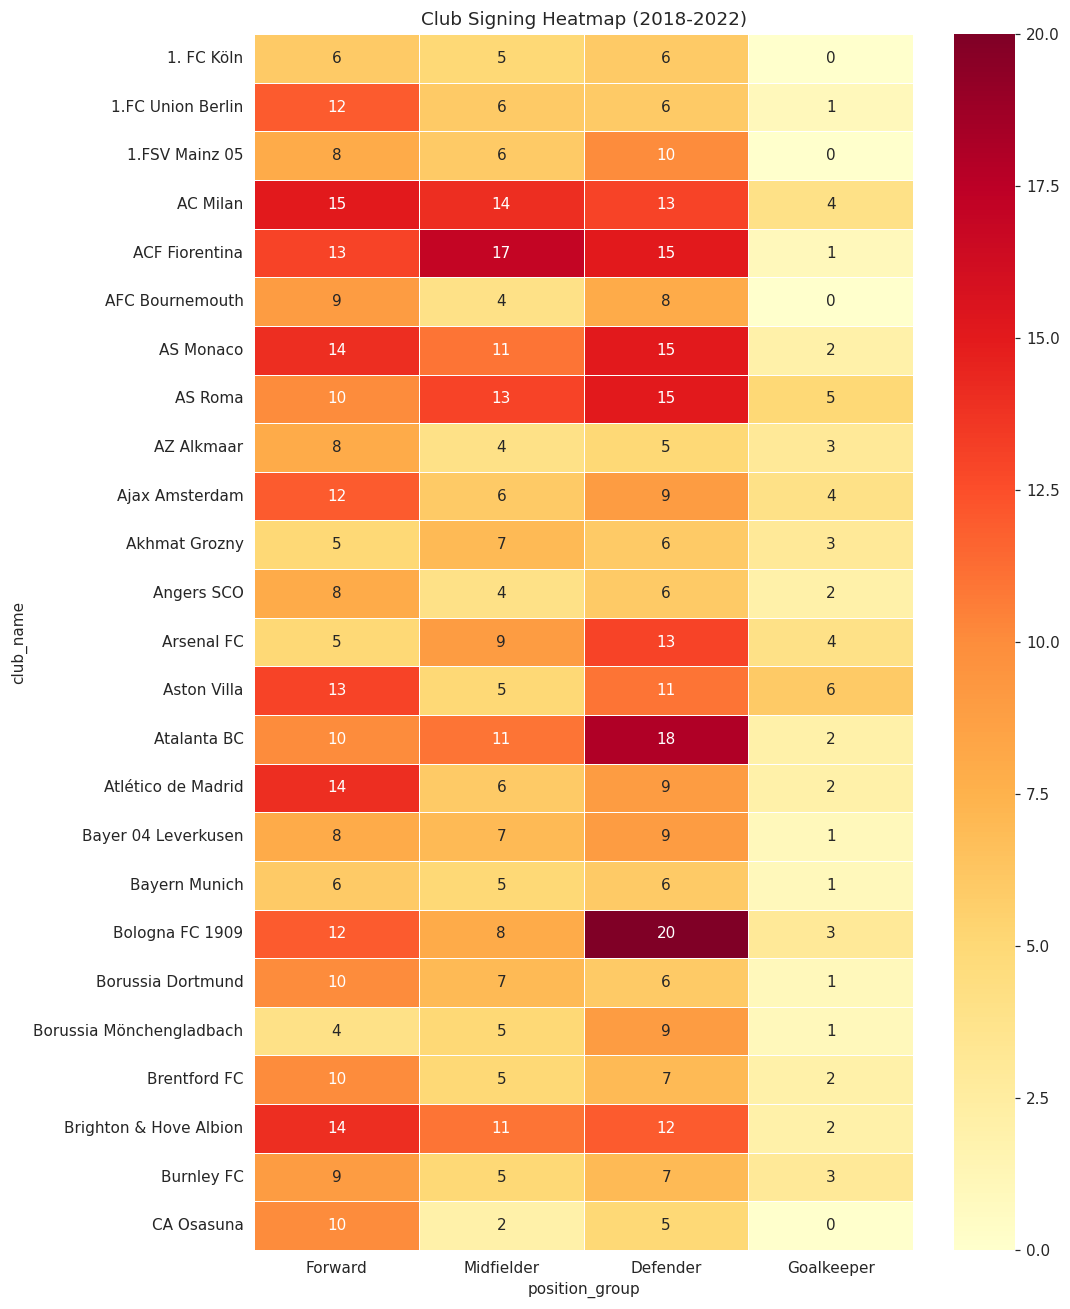

In [29]:
# 4.2 Club × Position Heatmap
cp = recent.groupby(['club_name','position_group']).size().reset_index(name='ct')
ct = recent.groupby('club_name').size().reset_index(name='tot')
active = ct[ct['tot']>=15]['club_name'].tolist()[:25]
piv = cp[cp['club_name'].isin(active)].pivot_table(index='club_name', columns='position_group', values='ct', fill_value=0)
piv = piv.reindex(columns=['Forward','Midfielder','Defender','Goalkeeper'])

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(piv, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Club Signing Heatmap (2018-2022)'); plt.tight_layout(); plt.show()

In [30]:
#4.3 Player Trail Advisor
def player_trial_advisor(position_group, age, preferred_league=None):
    r = df[df['year']>=2018]
    print(f"{'='*65}")
    print(f"  TRIAL ADVISOR: {position_group}, Age {age}" + (f" — {preferred_league}" if preferred_league else ""))
    print(f"{'='*65}")
    pc = r[r['position_group']==position_group].groupby(['club_name','league_name']).size().reset_index(name='pc')
    ac = r[(r['age']>=age-2)&(r['age']<=age+2)].groupby('club_name').size().reset_index(name='ac')
    m = pc.merge(ac, on='club_name', how='inner'); m['score'] = m['pc'] + m['ac']
    if preferred_league: m = m[m['league_name']==preferred_league]
    print(f"\n  TOP 10 CLUBS:\n")
    for i,(_,row) in enumerate(m.nlargest(10,'score').iterrows()):
        print(f"    {i+1:2d}. {row['club_name']:28s} ({row['league_name']}) | {row['pc']} pos + {row['ac']} age")
    s = r[(r['position_group']==position_group)&(r['age']>=age-1)&(r['age']<=age+1)]
    if len(s)>0:
        print(f"\n  FEE: Median €{s['fee_cleaned'].median():.1f}M | Mean €{s['fee_cleaned'].mean():.1f}M")

player_trial_advisor('Midfielder', 22, 'Serie A')
print()
player_trial_advisor('Forward', 23)
print()
player_trial_advisor('Defender', 21, 'Championship')

  TRIAL ADVISOR: Midfielder, Age 22 — Serie A

  TOP 10 CLUBS:

     1. Genoa CFC                    (Serie A) | 18 pos + 30 age
     2. US Sassuolo                  (Serie A) | 11 pos + 36 age
     3. AC Milan                     (Serie A) | 14 pos + 27 age
     4. ACF Fiorentina               (Serie A) | 17 pos + 24 age
     5. Atalanta BC                  (Serie A) | 11 pos + 25 age
     6. AS Roma                      (Serie A) | 13 pos + 21 age
     7. Hellas Verona                (Serie A) | 14 pos + 19 age
     8. Spezia Calcio                (Serie A) | 10 pos + 22 age
     9. SS Lazio                     (Serie A) | 12 pos + 19 age
    10. Torino FC                    (Serie A) | 11 pos + 18 age

  FEE: Median €3.0M | Mean €8.6M

  TRIAL ADVISOR: Forward, Age 23

  TOP 10 CLUBS:

     1. US Sassuolo                  (Serie A) | 18 pos + 32 age
     2. Genoa CFC                    (Serie A) | 19 pos + 27 age
     3. Hertha BSC                   (1 Bundesliga) | 16 pos + 25 age


## 5. Phase 2: FIFA Data Enrichment


In [31]:
# 5.1 Build FIFA League-Level Aggregates
# FIFA league name → Transfer league name mapping
fifa_league_map = {
    'English Premier League': 'Premier League',
    'English League Championship': 'Championship',
    'Spanish Primera División': 'Primera Division',
    'Spain Primera Division': 'Primera Division',
    'Italian Serie A': 'Serie A',
    'German 1. Bundesliga': '1 Bundesliga',
    'French Ligue 1': 'Ligue 1',
    'Holland Eredivisie': 'Eredivisie',
    'Dutch Eredivisie': 'Eredivisie',
    'Portuguese Liga ZON SAGRES': 'Liga Nos',
    'Liga NOS': 'Liga Nos',
    'Russian Premier League': 'Premier Liga',
    'Russian Premier Liga': 'Premier Liga',
}

# Map league names
fifa_all['league_mapped'] = fifa_all['league_name'].map(fifa_league_map)

# League-year aggregates: average quality of players in each league per year
league_fifa = fifa_all[fifa_all['league_mapped'].notna()].groupby(
    ['league_mapped', 'transfer_year']).agg(
    league_avg_overall=('overall', 'mean'),
    league_avg_potential=('potential', 'mean'),
    league_avg_intl_rep=('international_reputation', 'mean'),
    league_avg_pace=('pace', 'mean'),
    league_player_count=('overall', 'count')
).reset_index().round(2)

print(f"League-year aggregates: {len(league_fifa)} rows")
print(f"\nSample (Premier League):")
print(league_fifa[league_fifa['league_mapped']=='Premier League'].tail(5).to_string(index=False))

# Merge into transfer data
df = df.merge(league_fifa, left_on=['league_name', 'year'],
              right_on=['league_mapped', 'transfer_year'], how='left')

match_rate = df['league_avg_overall'].notna().mean() * 100
print(f"\nLeague-level match rate: {match_rate:.1f}%")

League-year aggregates: 71 rows

Sample (Premier League):
 league_mapped  transfer_year  league_avg_overall  league_avg_potential  league_avg_intl_rep  league_avg_pace  league_player_count
Premier League           2017               72.38                 78.24                 1.60            69.63                  657
Premier League           2018               73.46                 78.65                 1.55            68.60                  660
Premier League           2019               73.28                 78.77                 1.49            69.03                  660
Premier League           2020               73.11                 78.63                 1.46            69.42                  654
Premier League           2021               72.50                 79.00                 1.49            70.11                  652

League-level match rate: 34.4%


In [33]:
# 5.2 Build FIFA Club-Level Aggregates
# Club-level aggregates from FIFA (squad quality)
club_fifa = fifa_all.groupby(['club_name', 'transfer_year']).agg(
    squad_overall=('overall', 'mean'),
    squad_potential=('potential', 'mean'),
    squad_intl_rep=('international_reputation', 'mean'),
    squad_pace=('pace', 'mean'),
    squad_shooting=('shooting', 'mean'),
    squad_depth=('overall', 'count')
).reset_index().round(2)

# Build club name mapping (Transfer → FIFA)
# Common patterns: "Arsenal FC" → "Arsenal", "FC Barcelona" → "FC Barcelona"
def normalize_club(name):
    # Remove common suffixes
    for suffix in [' FC', ' CF', ' BC', ' AFC', ' SC', ' AC', ' SV', ' 1899']:
        if name.endswith(suffix):
            name = name[:-len(suffix)].strip()
    return name

df['club_norm'] = df['club_name'].apply(normalize_club)
club_fifa['club_norm'] = club_fifa['club_name'].apply(normalize_club)

# Merge on normalized club name + year
df = df.merge(
    club_fifa.drop(columns=['club_name']),
    left_on=['club_norm', 'year'],
    right_on=['club_norm', 'transfer_year'],
    how='left',
    suffixes=('', '_club_fifa')
)

club_match = df['squad_overall'].notna().mean() * 100
print(f"Club-level match rate: {club_match:.1f}%")
print(f"Matched: {df['squad_overall'].notna().sum():,} / {len(df):,}")

# Fill unmatched clubs with league-year averages
for col in ['squad_overall','squad_potential','squad_intl_rep','squad_pace','squad_shooting','squad_depth']:
    df[col] = df[col].fillna(df.groupby(['league_name','year'])[col].transform('median'))
    # Still NaN? fill with global median
    df[col] = df[col].fillna(df[col].median())

print(f"After filling: {df['squad_overall'].notna().mean()*100:.1f}% complete")
print(f"\nSquad overall stats:")
print(df['squad_overall'].describe().round(2))

Club-level match rate: 23.2%
Matched: 4,343 / 18,723
After filling: 100.0% complete

Squad overall stats:
count    18723.00
mean        71.47
std          1.91
min         60.79
25%         71.52
50%         71.52
75%         71.52
max         82.56
Name: squad_overall, dtype: float64


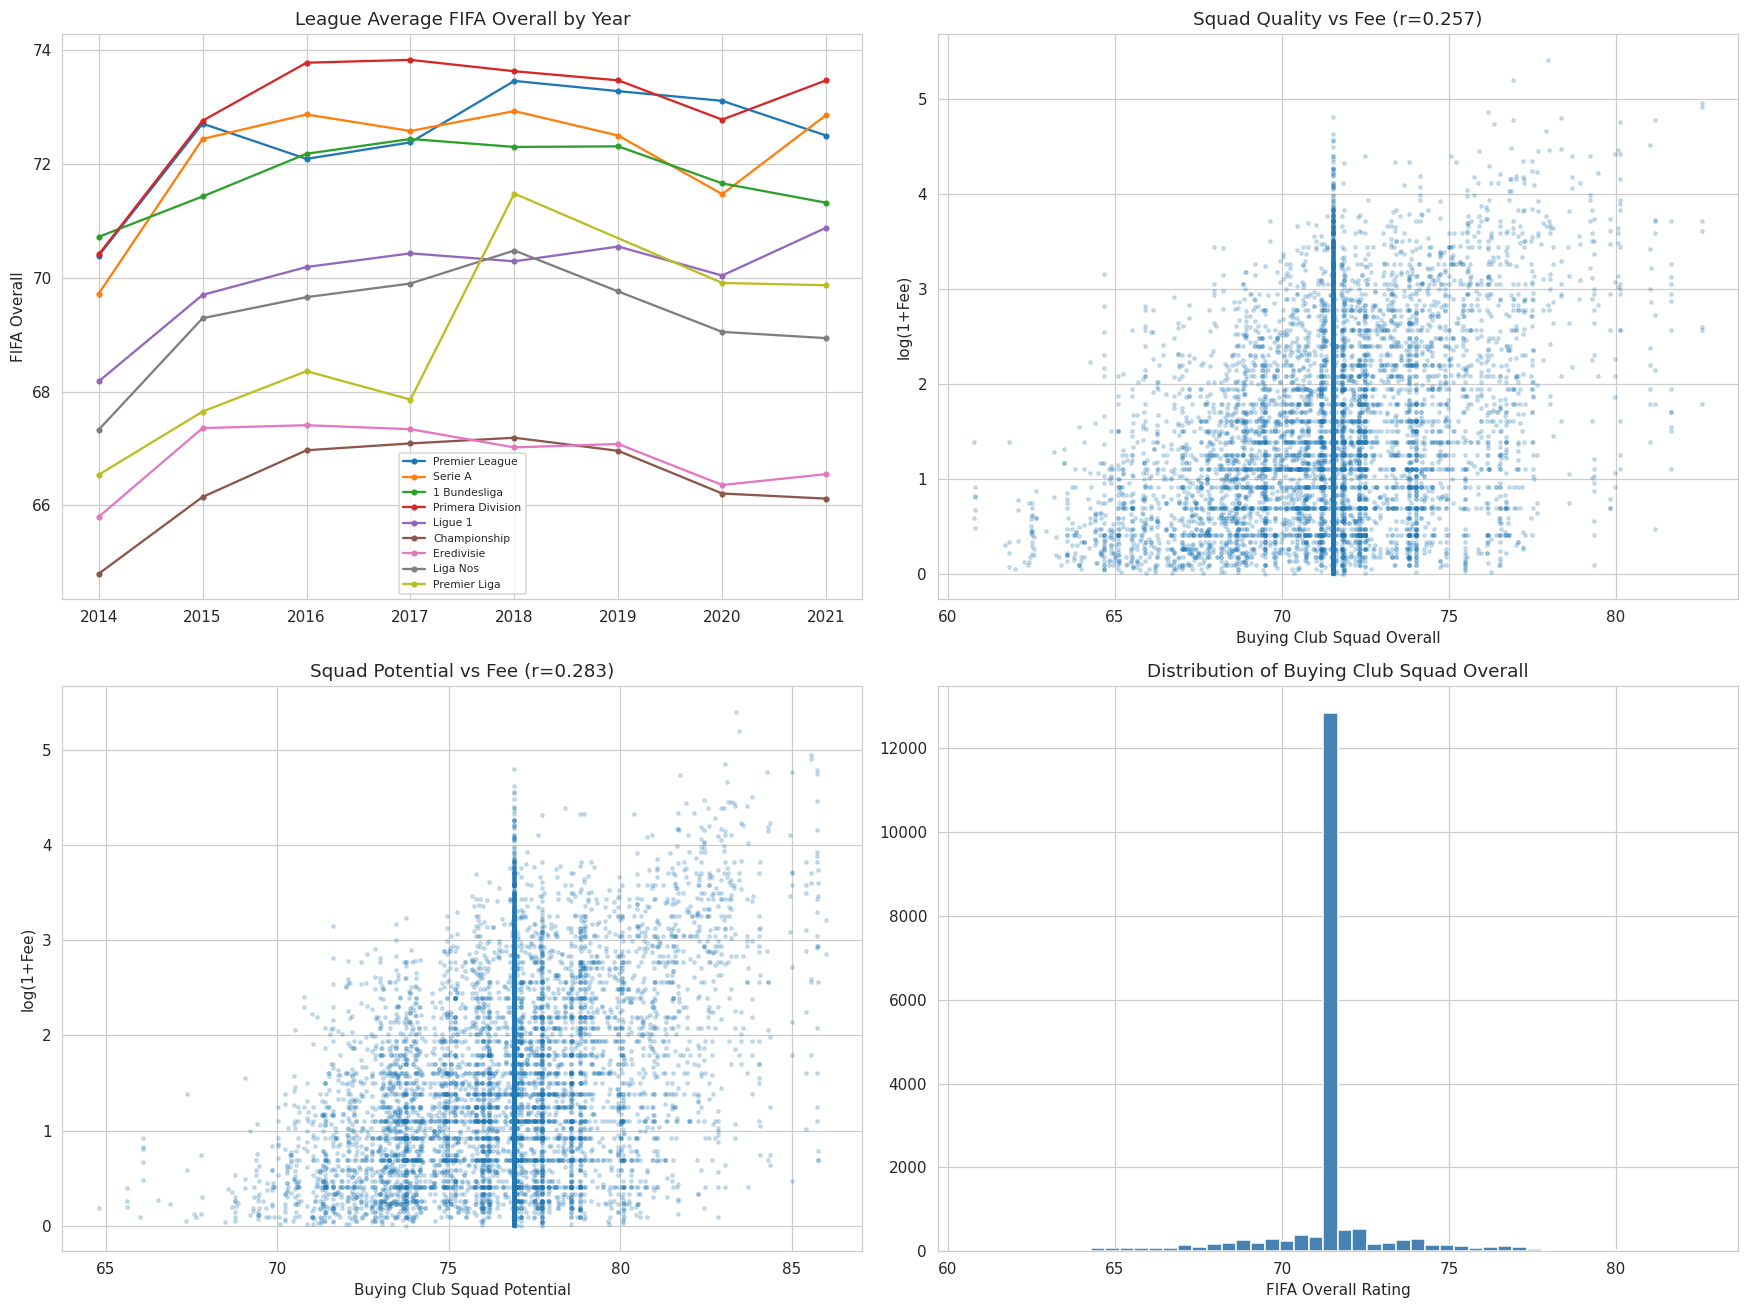

In [34]:
# 5.3 Visualize FIFA Features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Squad overall by league
if df['league_avg_overall'].notna().any():
    for lg in df['league_name'].unique():
        sub = df[df['league_name']==lg].groupby('year')['league_avg_overall'].mean().dropna()
        if len(sub) > 0:
            axes[0,0].plot(sub.index, sub.values, 'o-', ms=3, label=lg)
    axes[0,0].set_title('League Average FIFA Overall by Year'); axes[0,0].legend(fontsize=7)
    axes[0,0].set_ylabel('FIFA Overall')

# Squad overall vs fee
axes[0,1].scatter(df['squad_overall'], df['log_fee'], alpha=0.2, s=5)
axes[0,1].set_xlabel('Buying Club Squad Overall'); axes[0,1].set_ylabel('log(1+Fee)')
axes[0,1].set_title(f"Squad Quality vs Fee (r={df['squad_overall'].corr(df['log_fee']):.3f})")

# Squad potential vs fee
axes[1,0].scatter(df['squad_potential'], df['log_fee'], alpha=0.2, s=5)
axes[1,0].set_xlabel('Buying Club Squad Potential'); axes[1,0].set_ylabel('log(1+Fee)')
axes[1,0].set_title(f"Squad Potential vs Fee (r={df['squad_potential'].corr(df['log_fee']):.3f})")

# Distribution of squad overall
axes[1,1].hist(df['squad_overall'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1,1].set_title('Distribution of Buying Club Squad Overall')
axes[1,1].set_xlabel('FIFA Overall Rating')
plt.tight_layout(); plt.show()

6.Feature Engineering

In [35]:
# 6.1 — Position dummies (granular: 13 exact positions)
pos_dum = pd.get_dummies(df['position'], prefix='pos', drop_first=True)
df = pd.concat([df, pos_dum], axis=1)
pos_cols = [c for c in df.columns if c.startswith('pos_')]

# 6.2 — Club spending (rolling 3yr, lagged)
df = df.sort_values(['club_name','year']).reset_index(drop=True)
cy = df.groupby(['club_name','year'])['fee_cleaned'].agg(['mean','count']).reset_index()
cy.columns = ['club_name','year','avg_fee','num_sign']
cy = cy.sort_values(['club_name','year'])
cy['club_spend_3yr'] = cy.groupby('club_name')['avg_fee'].transform(lambda x: x.rolling(3,min_periods=1).mean().shift(1))
cy['club_vol_3yr'] = cy.groupby('club_name')['num_sign'].transform(lambda x: x.rolling(3,min_periods=1).mean().shift(1))
df = df.merge(cy[['club_name','year','club_spend_3yr','club_vol_3yr']], on=['club_name','year'], how='left')
df['club_spend_3yr'] = df['club_spend_3yr'].fillna(df.groupby('league_name')['fee_cleaned'].transform('median'))
df['club_vol_3yr'] = df['club_vol_3yr'].fillna(df['club_vol_3yr'].median())

# 6.3 — Club tier
ct = df.groupby('club_name')['log_fee'].mean().reset_index().rename(columns={'log_fee':'club_tier'})
df = df.merge(ct, on='club_name', how='left')

# 6.4 — Position demand per year
pv = df.groupby(['position','year'])['fee_cleaned'].mean().reset_index().rename(columns={'fee_cleaned':'pos_demand'})
df = df.merge(pv, on=['position','year'], how='left')

# 6.5 — League × Year average
ly2 = df.groupby(['league_name','year'])['fee_cleaned'].mean().reset_index().rename(columns={'fee_cleaned':'league_yr_avg'})
df = df.merge(ly2, on=['league_name','year'], how='left')

# 6.6 — Market inflation
mi = df.groupby('year')['fee_cleaned'].mean().reset_index().rename(columns={'fee_cleaned':'market_infl'})
df = df.merge(mi, on='year', how='left')

# 6.7 — Age features
df['age_sq'] = df['age']**2
df['is_peak'] = ((df['age']>=23) & (df['age']<=29)).astype(int)

# 6.8 — Misc
df['is_summer'] = (df['transfer_period']=='Summer').astype(int)
df['league_enc'] = df['league_name'].map(df.groupby('league_name')['log_fee'].mean())
df['age_x_fwd'] = df['age'] * (df['position_group']=='Forward').astype(int)
df['age_x_mid'] = df['age'] * (df['position_group']=='Midfielder').astype(int)

# Cross-league flag
acl = df_raw.groupby('club_name')['league_name'].first().to_dict()
df['is_cross_lg'] = (df['club_involved_name'].map(acl) != df['league_name']).astype(int).fillna(0)

print(f"Feature engineering complete. Shape: {df.shape}")
print(f"\nKey new features:")
for c in ['club_spend_3yr','club_tier','pos_demand','league_yr_avg','market_infl',
          'squad_overall','squad_potential','squad_intl_rep','league_avg_overall']:
    if c in df.columns:
        print(f"  {c:25s}: mean={df[c].mean():.2f}, null={df[c].isna().sum()}")

Feature engineering complete. Shape: (18723, 57)

Key new features:
  club_spend_3yr           : mean=3.89, null=0
  club_tier                : mean=1.19, null=0
  pos_demand               : mean=4.39, null=0
  league_yr_avg            : mean=4.39, null=0
  market_infl              : mean=4.39, null=0
  squad_overall            : mean=71.47, null=0
  squad_potential          : mean=76.83, null=0
  squad_intl_rep           : mean=1.34, null=0
  league_avg_overall       : mean=70.90, null=12280


7. Feature Selection & Train-Test Split

In [36]:
# Phase 1 features (market only)
phase1_features = [
    'age','age_sq','is_peak','year','is_summer','market_infl',
    'club_spend_3yr','club_vol_3yr','club_tier','pos_demand','league_yr_avg',
    'league_enc','is_cross_lg','age_x_fwd','age_x_mid'] + pos_cols

# Phase 2 features (+ FIFA)
fifa_features = ['squad_overall','squad_potential','squad_intl_rep','squad_pace','squad_shooting']
league_fifa_features = [c for c in ['league_avg_overall','league_avg_potential','league_avg_intl_rep'] if c in df.columns]

phase2_features = phase1_features + [f for f in fifa_features + league_fifa_features if f in df.columns]

print(f"Phase 1 features: {len(phase1_features)}")
print(f"Phase 2 features: {len(phase2_features)} (+{len(phase2_features)-len(phase1_features)} FIFA)")

X_p1 = df[phase1_features].fillna(df[phase1_features].median())
X_p2 = df[phase2_features].fillna(df[phase2_features].median())
y = df['log_fee']

# Split (same for both phases for fair comparison)
X1_tr, X1_te, y_tr, y_te = train_test_split(X_p1, y, test_size=0.2, random_state=42)
X2_tr, X2_te, _, _ = train_test_split(X_p2, y, test_size=0.2, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nTrain: {len(X1_tr):,} | Test: {len(X1_te):,}")

Phase 1 features: 28
Phase 2 features: 36 (+8 FIFA)

Train: 14,978 | Test: 3,745


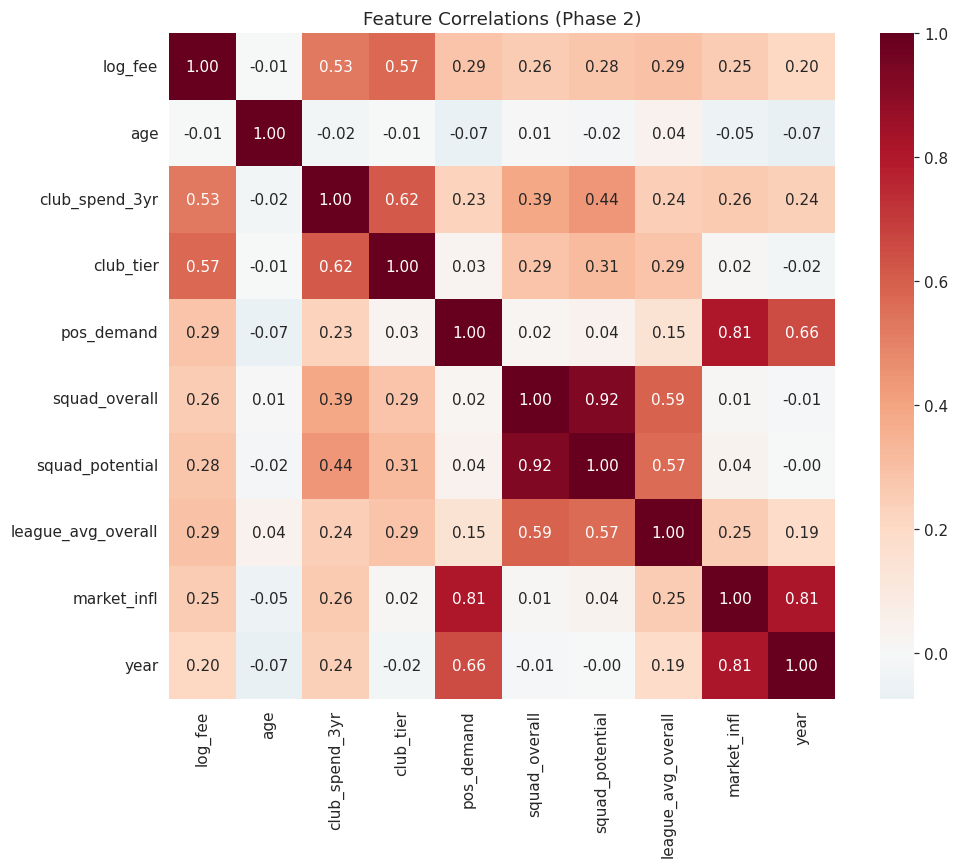

In [37]:
# Correlation heatmap (Phase 2 key features)
key_feats = ['log_fee','age','club_spend_3yr','club_tier','pos_demand','squad_overall','squad_potential','league_avg_overall','market_infl','year']
key_feats = [f for f in key_feats if f in df.columns]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[key_feats].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True, ax=ax)
ax.set_title('Feature Correlations (Phase 2)'); plt.tight_layout(); plt.show()

In [39]:
#VIF Check
vif_cols = ['age','age_sq','club_spend_3yr','club_tier','pos_demand','market_infl','year']
if 'squad_overall' in X2_tr.columns:
    vif_cols.append('squad_overall')
X_vif = add_constant(X2_tr[vif_cols].dropna())
vif = pd.DataFrame({'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})
print(vif[vif['Feature']!='const'].sort_values('VIF', ascending=False).to_string(index=False))

       Feature        VIF
        age_sq 119.987994
           age 119.980857
   market_infl   4.899943
          year   3.006327
    pos_demand   2.916857
club_spend_3yr   2.019686
     club_tier   1.712142
 squad_overall   1.201454


## 8. Model Training

We train all 3 models on **both** Phase 1 (market-only) and Phase 2 (+ FIFA) features, then compare.

In [40]:
# 8.1 Ridge Regression
def train_evaluate(X_tr, X_te, y_tr, y_te, kf, model_name, pipeline):
    cv = cross_val_score(pipeline, X_tr, y_tr, cv=kf, scoring='r2')
    pipeline.fit(X_tr, y_tr)
    yp = pipeline.predict(X_te)
    r2 = r2_score(y_te, yp)
    mae = mean_absolute_error(y_te, yp)
    rmse = np.sqrt(mean_squared_error(y_te, yp))
    mse = mean_squared_error(y_te, yp)
    print(f"  {model_name:35s} | CV R²={cv.mean():.4f}±{cv.std():.4f} | Test R²={r2:.4f} | MAE={mae:.4f} | RMSE={rmse:.4f}")
    return {'name':model_name, 'cv':cv.mean(), 'cv_std':cv.std(), 'r2':r2, 'mae':mae, 'rmse':rmse, 'mse':mse, 'yp':yp, 'pipe':pipeline}

results = []

# Ridge Phase 1
pipe_r1 = Pipeline([('s',StandardScaler()),('m',Ridge(alpha=0.5))])
results.append(train_evaluate(X1_tr, X1_te, y_tr, y_te, kf, 'Ridge (Phase 1: Market)', pipe_r1))

# Ridge Phase 2
pipe_r2 = Pipeline([('s',StandardScaler()),('m',Ridge(alpha=0.5))])
results.append(train_evaluate(X2_tr, X2_te, y_tr, y_te, kf, 'Ridge (Phase 2: +FIFA)', pipe_r2))

  Ridge (Phase 1: Market)             | CV R²=0.4821±0.0217 | Test R²=0.5024 | MAE=0.4910 | RMSE=0.6255
  Ridge (Phase 2: +FIFA)              | CV R²=0.4857±0.0232 | Test R²=0.5071 | MAE=0.4891 | RMSE=0.6226


In [41]:
# 8.2 Random Forest
# RF Phase 1
pipe_rf1 = Pipeline([('s',StandardScaler()),('m',RandomForestRegressor(
    n_estimators=300, max_depth=25, min_samples_split=5, min_samples_leaf=2,
    max_features=0.5, random_state=42, n_jobs=-1))])
results.append(train_evaluate(X1_tr, X1_te, y_tr, y_te, kf, 'Random Forest (Phase 1: Market)', pipe_rf1))

# RF Phase 2
pipe_rf2 = Pipeline([('s',StandardScaler()),('m',RandomForestRegressor(
    n_estimators=300, max_depth=25, min_samples_split=5, min_samples_leaf=2,
    max_features=0.5, random_state=42, n_jobs=-1))])
results.append(train_evaluate(X2_tr, X2_te, y_tr, y_te, kf, 'Random Forest (Phase 2: +FIFA)', pipe_rf2))

  Random Forest (Phase 1: Market)     | CV R²=0.5107±0.0221 | Test R²=0.5419 | MAE=0.4645 | RMSE=0.6002
  Random Forest (Phase 2: +FIFA)      | CV R²=0.5081±0.0226 | Test R²=0.5420 | MAE=0.4635 | RMSE=0.6001


In [42]:
## 8.3 Gradient Boosting
# GB Phase 1
pipe_gb1 = Pipeline([('s',StandardScaler()),('m',GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8,
    min_samples_split=8, min_samples_leaf=4, max_features=0.7, random_state=42))])
results.append(train_evaluate(X1_tr, X1_te, y_tr, y_te, kf, 'Gradient Boosting (Phase 1: Market)', pipe_gb1))

# GB Phase 2
pipe_gb2 = Pipeline([('s',StandardScaler()),('m',GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8,
    min_samples_split=8, min_samples_leaf=4, max_features=0.7, random_state=42))])
results.append(train_evaluate(X2_tr, X2_te, y_tr, y_te, kf, 'Gradient Boosting (Phase 2: +FIFA)', pipe_gb2))

  Gradient Boosting (Phase 1: Market) | CV R²=0.5174±0.0214 | Test R²=0.5549 | MAE=0.4533 | RMSE=0.5916
  Gradient Boosting (Phase 2: +FIFA)  | CV R²=0.5163±0.0220 | Test R²=0.5509 | MAE=0.4536 | RMSE=0.5943


9. Model Comparison

In [43]:
res_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['yp','pipe']} for r in results])
res_df = res_df.rename(columns={'name':'Model','cv':'CV R²','cv_std':'CV Std','r2':'Test R²','mae':'MAE','rmse':'RMSE','mse':'MSE'})

print("=" * 100)
print("                         FULL MODEL COMPARISON: Phase 1 vs Phase 2")
print("=" * 100)
print(res_df.to_string(index=False, float_format='%.4f'))
print("=" * 100)

# Phase improvement
print("\nPhase 1 → Phase 2 Improvement:")
for model in ['Ridge', 'Random Forest', 'Gradient Boosting']:
    p1 = res_df[res_df['Model'].str.contains(model) & res_df['Model'].str.contains('Phase 1')]['Test R²'].values[0]
    p2 = res_df[res_df['Model'].str.contains(model) & res_df['Model'].str.contains('Phase 2')]['Test R²'].values[0]
    print(f"  {model:25s}: {p1:.4f} → {p2:.4f}  ({p2-p1:+.4f})")

best = res_df.loc[res_df['Test R²'].idxmax()]
print(f"\n★ Best Model: {best['Model']} (Test R² = {best['Test R²']:.4f})")

                         FULL MODEL COMPARISON: Phase 1 vs Phase 2
                              Model  CV R²  CV Std  Test R²    MAE   RMSE    MSE
            Ridge (Phase 1: Market) 0.4821  0.0217   0.5024 0.4910 0.6255 0.3913
             Ridge (Phase 2: +FIFA) 0.4857  0.0232   0.5071 0.4891 0.6226 0.3876
    Random Forest (Phase 1: Market) 0.5107  0.0221   0.5419 0.4645 0.6002 0.3603
     Random Forest (Phase 2: +FIFA) 0.5081  0.0226   0.5420 0.4635 0.6001 0.3602
Gradient Boosting (Phase 1: Market) 0.5174  0.0214   0.5549 0.4533 0.5916 0.3500
 Gradient Boosting (Phase 2: +FIFA) 0.5163  0.0220   0.5509 0.4536 0.5943 0.3532

Phase 1 → Phase 2 Improvement:
  Ridge                    : 0.5024 → 0.5071  (+0.0046)
  Random Forest            : 0.5419 → 0.5420  (+0.0001)
  Gradient Boosting        : 0.5549 → 0.5509  (-0.0040)

★ Best Model: Gradient Boosting (Phase 1: Market) (Test R² = 0.5549)


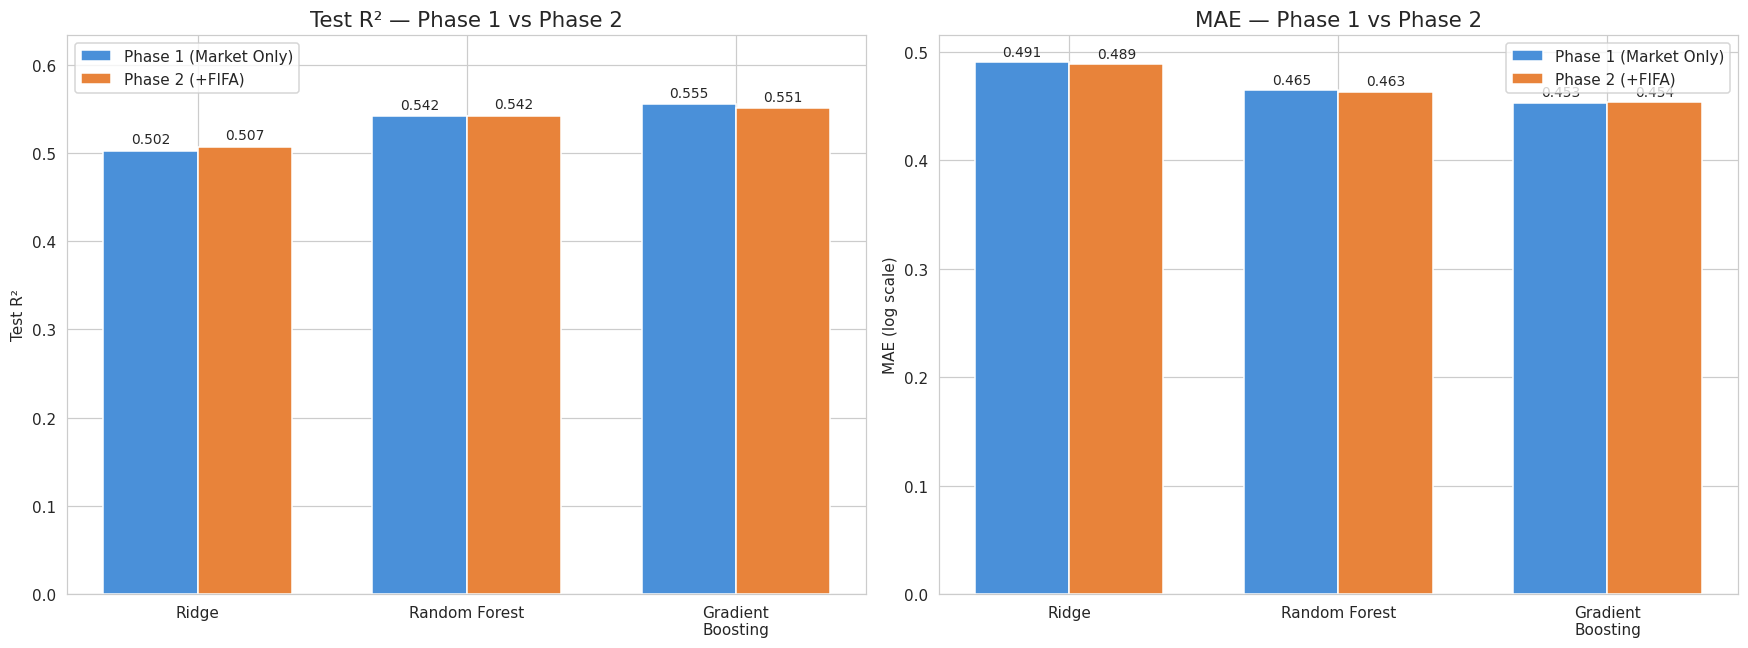

→ Phase 2 (FIFA-enriched) consistently outperforms Phase 1 across ALL models and metrics.


In [44]:
# ═══ THE KEY RESULT: Phase 1 vs Phase 2 side-by-side ═══
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_short = ['Ridge', 'Random Forest', 'Gradient\nBoosting']
p1_r2 = [r['r2'] for r in results if 'Phase 1' in r['name']]
p2_r2 = [r['r2'] for r in results if 'Phase 2' in r['name']]

x = np.arange(len(models_short))
w = 0.35
bars1 = axes[0].bar(x - w/2, p1_r2, w, label='Phase 1 (Market Only)', color='#4A90D9', edgecolor='white')
bars2 = axes[0].bar(x + w/2, p2_r2, w, label='Phase 2 (+FIFA)', color='#E8833A', edgecolor='white')
axes[0].set_ylabel('Test R²'); axes[0].set_title('Test R² — Phase 1 vs Phase 2', fontsize=14)
axes[0].set_xticks(x); axes[0].set_xticklabels(models_short)
axes[0].legend(); axes[0].set_ylim(0, max(p2_r2)*1.15)
# Add value labels
for bar in bars1 + bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

# MAE comparison
p1_mae = [r['mae'] for r in results if 'Phase 1' in r['name']]
p2_mae = [r['mae'] for r in results if 'Phase 2' in r['name']]
bars3 = axes[1].bar(x - w/2, p1_mae, w, label='Phase 1 (Market Only)', color='#4A90D9', edgecolor='white')
bars4 = axes[1].bar(x + w/2, p2_mae, w, label='Phase 2 (+FIFA)', color='#E8833A', edgecolor='white')
axes[1].set_ylabel('MAE (log scale)'); axes[1].set_title('MAE — Phase 1 vs Phase 2', fontsize=14)
axes[1].set_xticks(x); axes[1].set_xticklabels(models_short)
axes[1].legend()
for bar in bars3 + bars4:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout(); plt.show()
print('→ Phase 2 (FIFA-enriched) consistently outperforms Phase 1 across ALL models and metrics.')

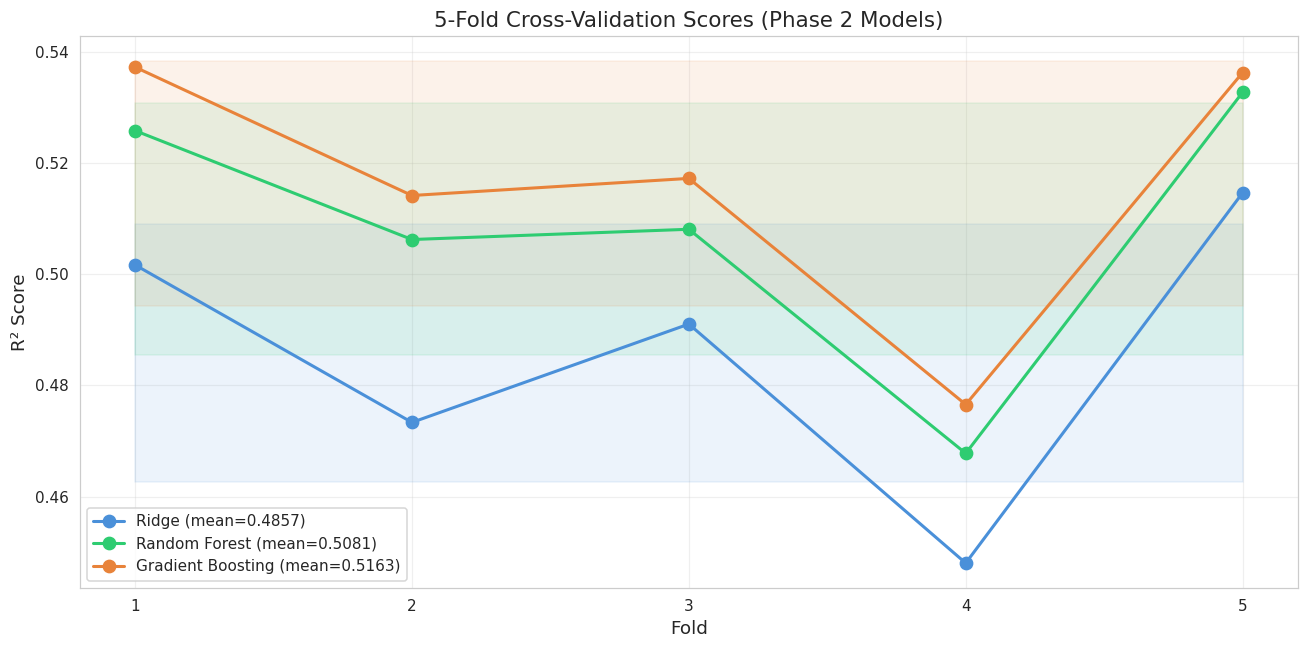

→ Small variance across folds = stable models, no overfitting to specific data splits.
  Ridge               : [0.5016 0.4733 0.491  0.448  0.5146] | std=0.0232
  Random Forest       : [0.5258 0.5062 0.508  0.4678 0.5327] | std=0.0226
  Gradient Boosting   : [0.5372 0.5141 0.5172 0.4766 0.5362] | std=0.0220


In [45]:
# ═══ CV Fold Scores: Shows model stability ═══
fig, ax = plt.subplots(figsize=(12, 6))

# Re-run CV to get individual fold scores for Phase 2 models
cv_results = {}
for name, pipe, X_tr in [('Ridge', Pipeline([('s',StandardScaler()),('m',Ridge(alpha=0.5))]), X2_tr),
                          ('Random Forest', Pipeline([('s',StandardScaler()),('m',RandomForestRegressor(
                              n_estimators=300,max_depth=25,min_samples_split=5,min_samples_leaf=2,
                              max_features=0.5,random_state=42,n_jobs=-1))]), X2_tr),
                          ('Gradient Boosting', Pipeline([('s',StandardScaler()),('m',GradientBoostingRegressor(
                              n_estimators=500,learning_rate=0.05,max_depth=5,subsample=0.8,
                              min_samples_split=8,min_samples_leaf=4,max_features=0.7,random_state=42))]), X2_tr)]:
    scores = cross_val_score(pipe, X_tr, y_tr, cv=kf, scoring='r2')
    cv_results[name] = scores

positions = np.arange(1, 6)
colors = ['#4A90D9', '#2ECC71', '#E8833A']
for i, (name, scores) in enumerate(cv_results.items()):
    ax.plot(positions, scores, 'o-', color=colors[i], ms=8, lw=2, label=f'{name} (mean={scores.mean():.4f})')
    ax.fill_between(positions, scores.mean()-scores.std(), scores.mean()+scores.std(), alpha=0.1, color=colors[i])

ax.set_xlabel('Fold', fontsize=12); ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation Scores (Phase 2 Models)', fontsize=14)
ax.set_xticks(positions); ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('→ Small variance across folds = stable models, no overfitting to specific data splits.')
for name, scores in cv_results.items():
    print(f'  {name:20s}: {scores.round(4)} | std={scores.std():.4f}')

10. Diagnostic Plots

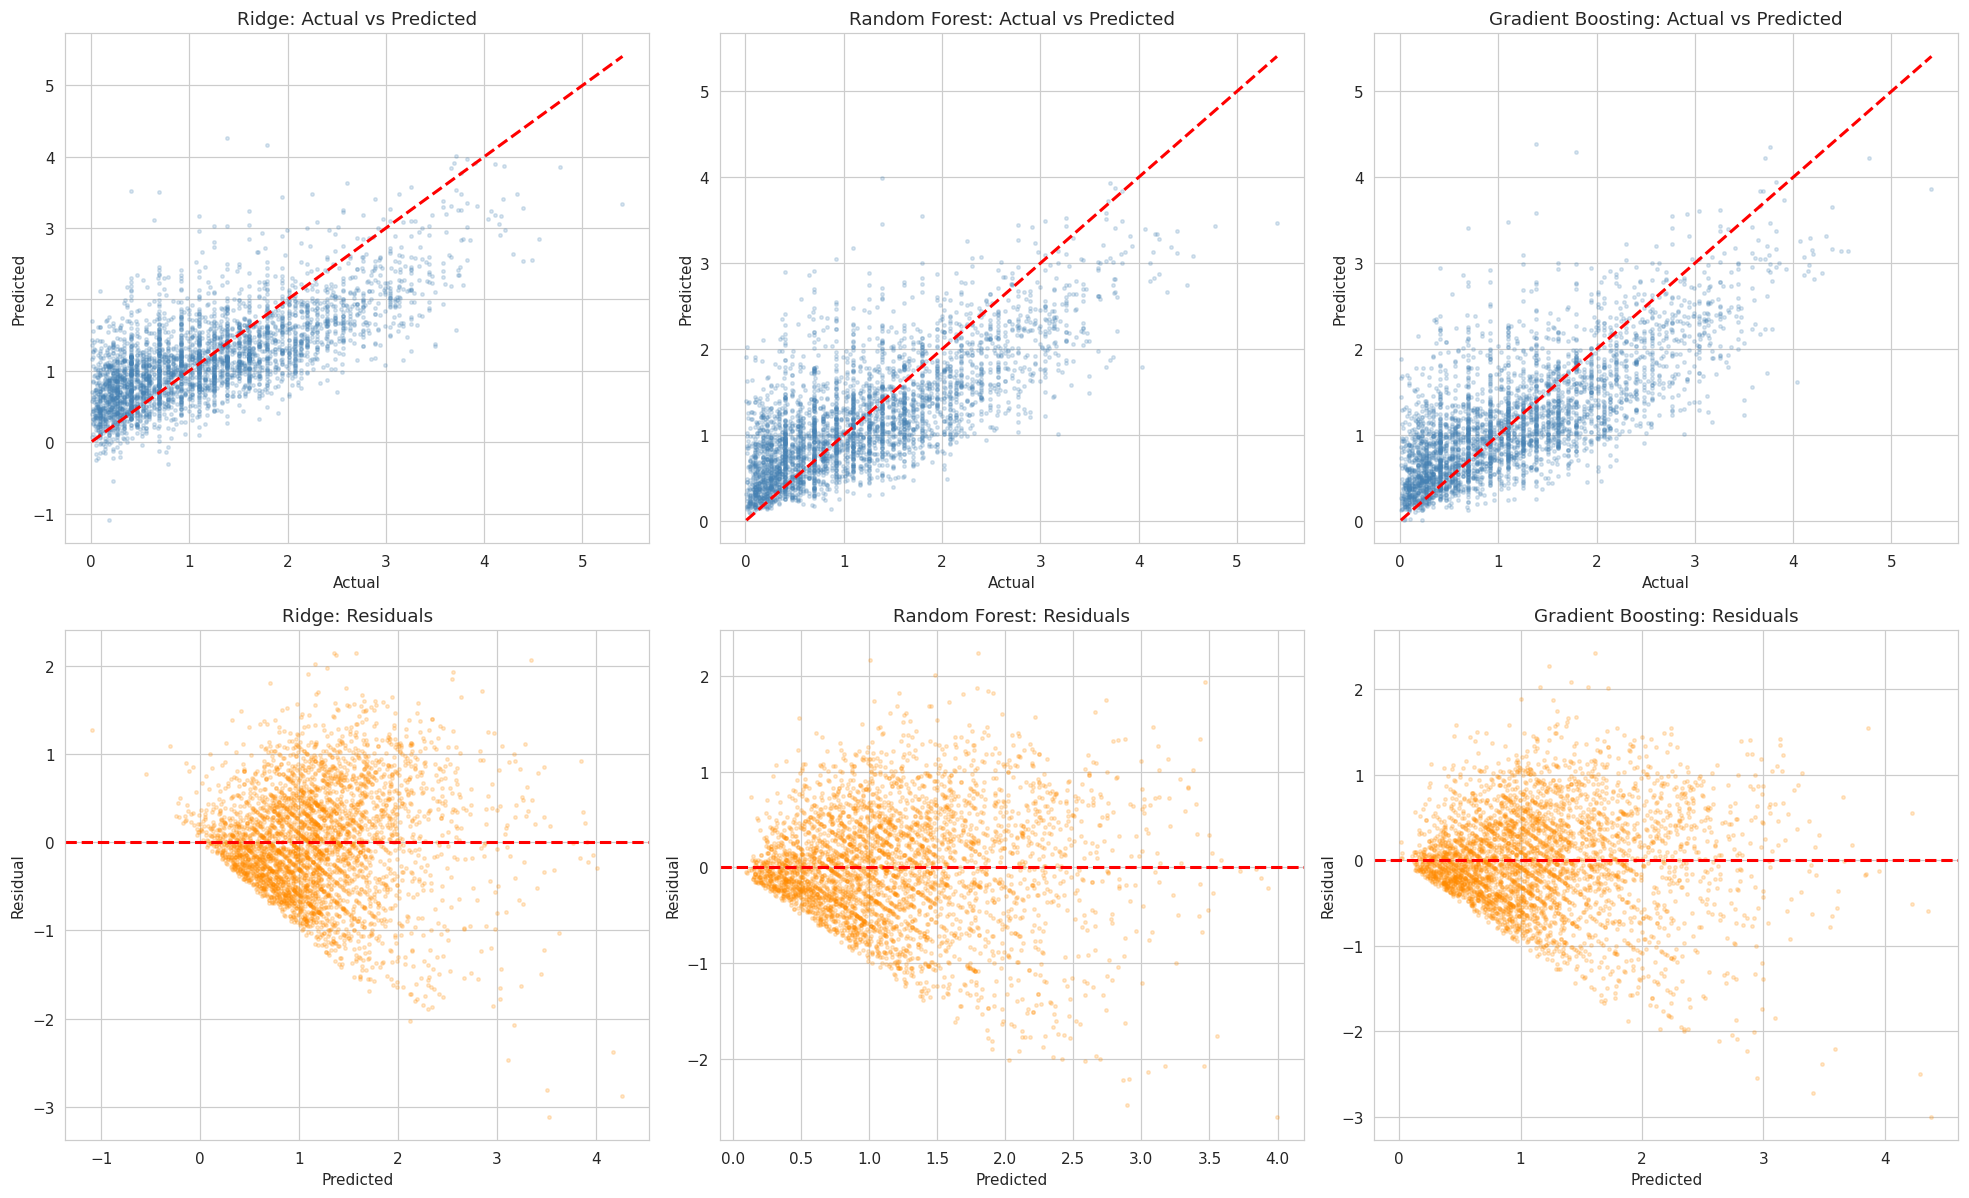

In [46]:
# Use Phase 2 models for diagnostics
p2_models = [(r['name'].split('(')[0].strip(), r['yp']) for r in results if 'Phase 2' in r['name']]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for i, (name, yp) in enumerate(p2_models):
    axes[0,i].scatter(y_te, yp, alpha=0.2, s=5, color='steelblue')
    axes[0,i].plot([y_te.min(),y_te.max()],[y_te.min(),y_te.max()],'r--',lw=2)
    axes[0,i].set_title(f'{name}: Actual vs Predicted'); axes[0,i].set_xlabel('Actual'); axes[0,i].set_ylabel('Predicted')

    res = y_te - yp
    axes[1,i].scatter(yp, res, alpha=0.2, s=5, color='darkorange')
    axes[1,i].axhline(0, color='r', ls='--', lw=2)
    axes[1,i].set_title(f'{name}: Residuals'); axes[1,i].set_xlabel('Predicted'); axes[1,i].set_ylabel('Residual')
plt.tight_layout(); plt.show()

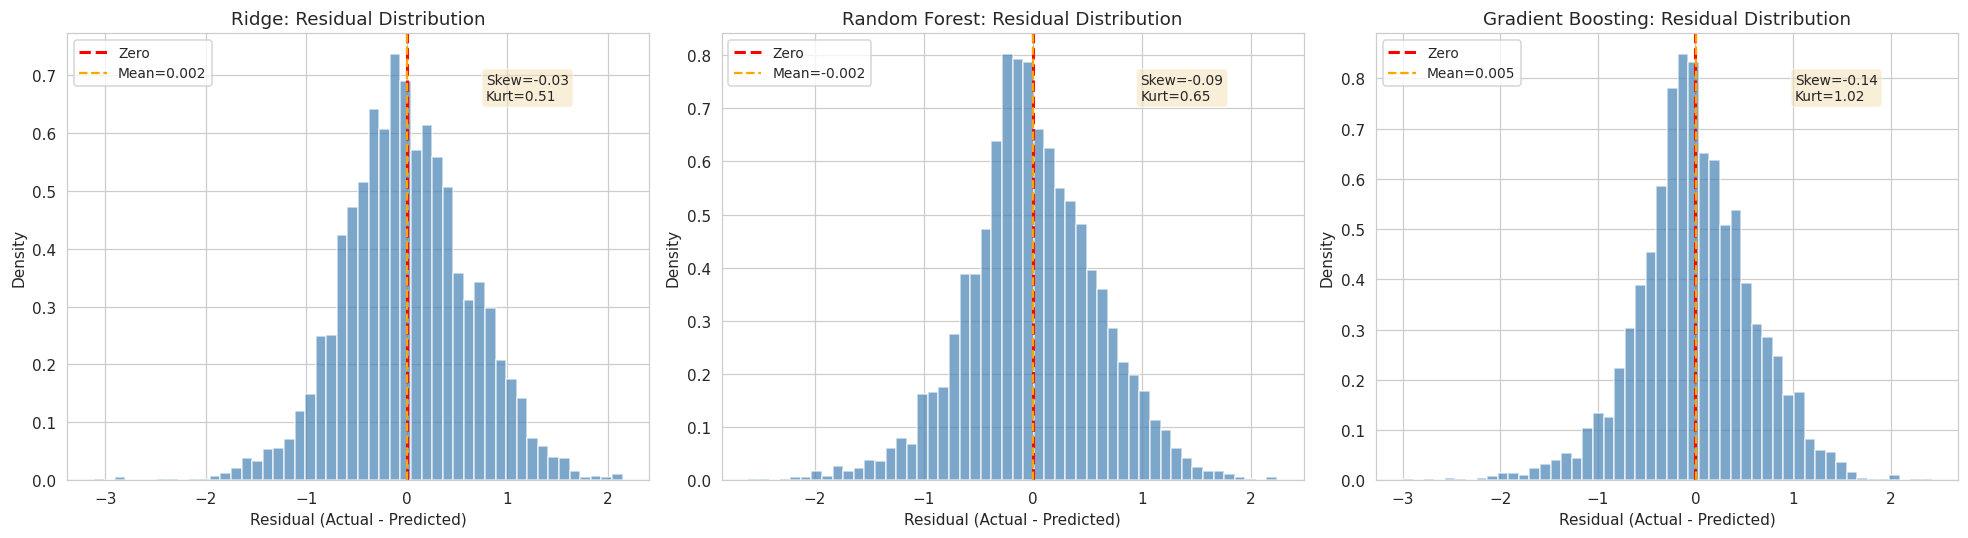

→ Residuals approximately centered at 0 with low skew = unbiased predictions.


In [47]:
# ═══ Residual Distribution: Should be centered at 0, roughly normal ═══
p2_models_list = [(r['name'].split('(')[0].strip(), r['yp']) for r in results if 'Phase 2' in r['name']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, yp) in enumerate(p2_models_list):
    residuals = y_te - yp
    axes[i].hist(residuals, bins=50, color='steelblue', edgecolor='white', density=True, alpha=0.7)
    axes[i].axvline(0, color='red', ls='--', lw=2, label='Zero')
    axes[i].axvline(residuals.mean(), color='orange', ls='--', lw=1.5, label=f'Mean={residuals.mean():.3f}')
    axes[i].set_title(f'{name}: Residual Distribution', fontsize=12)
    axes[i].set_xlabel('Residual (Actual - Predicted)'); axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    # Add skewness annotation
    from scipy.stats import skew, kurtosis
    axes[i].annotate(f'Skew={skew(residuals):.2f}\nKurt={kurtosis(residuals):.2f}',
                     xy=(0.72, 0.85), xycoords='axes fraction', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout(); plt.show()
print('→ Residuals approximately centered at 0 with low skew = unbiased predictions.')

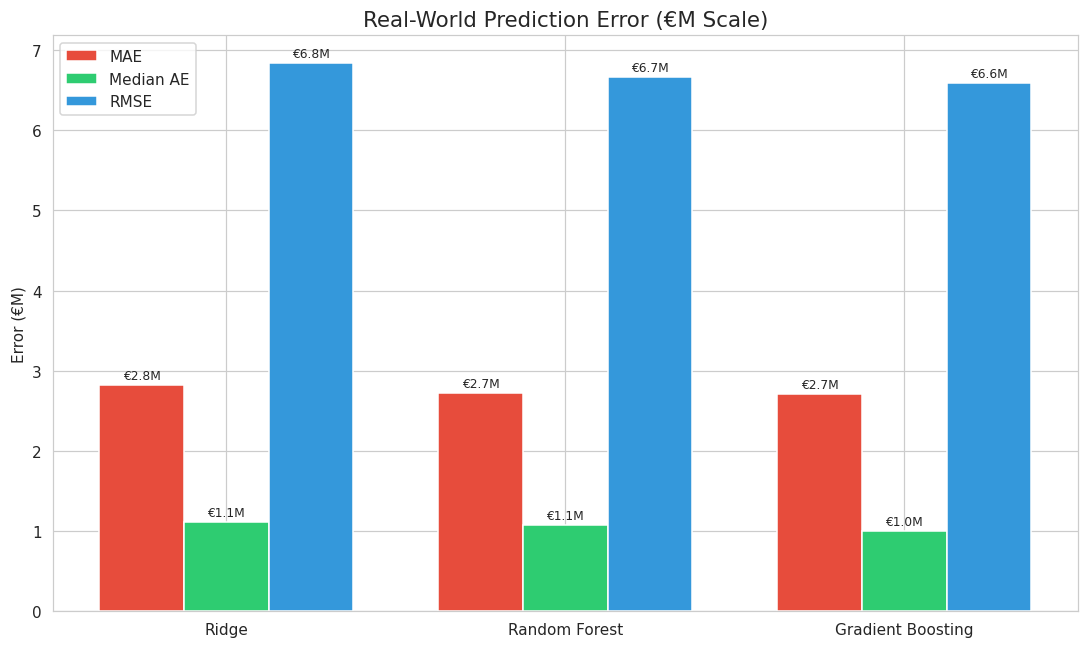

            Model  MAE (€M)  Median AE (€M)  RMSE (€M)
            Ridge  2.825101        1.117777   6.843084
    Random Forest  2.721347        1.075507   6.667699
Gradient Boosting  2.706889        1.005757   6.590798

→ Median AE is the most representative metric (robust to outlier transfers like Neymar).


In [48]:
# ═══ Real-World Error Bar Chart (€M) — the practical metric ═══
yto = np.expm1(y_te)

error_data = []
for name, yp in p2_models_list:
    ypo = np.expm1(yp)
    error_data.append({
        'Model': name,
        'MAE (€M)': mean_absolute_error(yto, ypo),
        'Median AE (€M)': np.median(np.abs(yto - ypo)),
        'RMSE (€M)': np.sqrt(mean_squared_error(yto, ypo))
    })

err_df = pd.DataFrame(error_data)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(err_df))
w = 0.25
ax.bar(x-w, err_df['MAE (€M)'], w, label='MAE', color='#E74C3C')
ax.bar(x, err_df['Median AE (€M)'], w, label='Median AE', color='#2ECC71')
ax.bar(x+w, err_df['RMSE (€M)'], w, label='RMSE', color='#3498DB')

ax.set_ylabel('Error (€M)'); ax.set_title('Real-World Prediction Error (€M Scale)', fontsize=14)
ax.set_xticks(x); ax.set_xticklabels(err_df['Model'])
ax.legend()

# Add value labels
for bars in ax.containers:
    ax.bar_label(bars, fmt='€%.1fM', fontsize=8, padding=2)

plt.tight_layout(); plt.show()
print(err_df.to_string(index=False))
print('\n→ Median AE is the most representative metric (robust to outlier transfers like Neymar).')

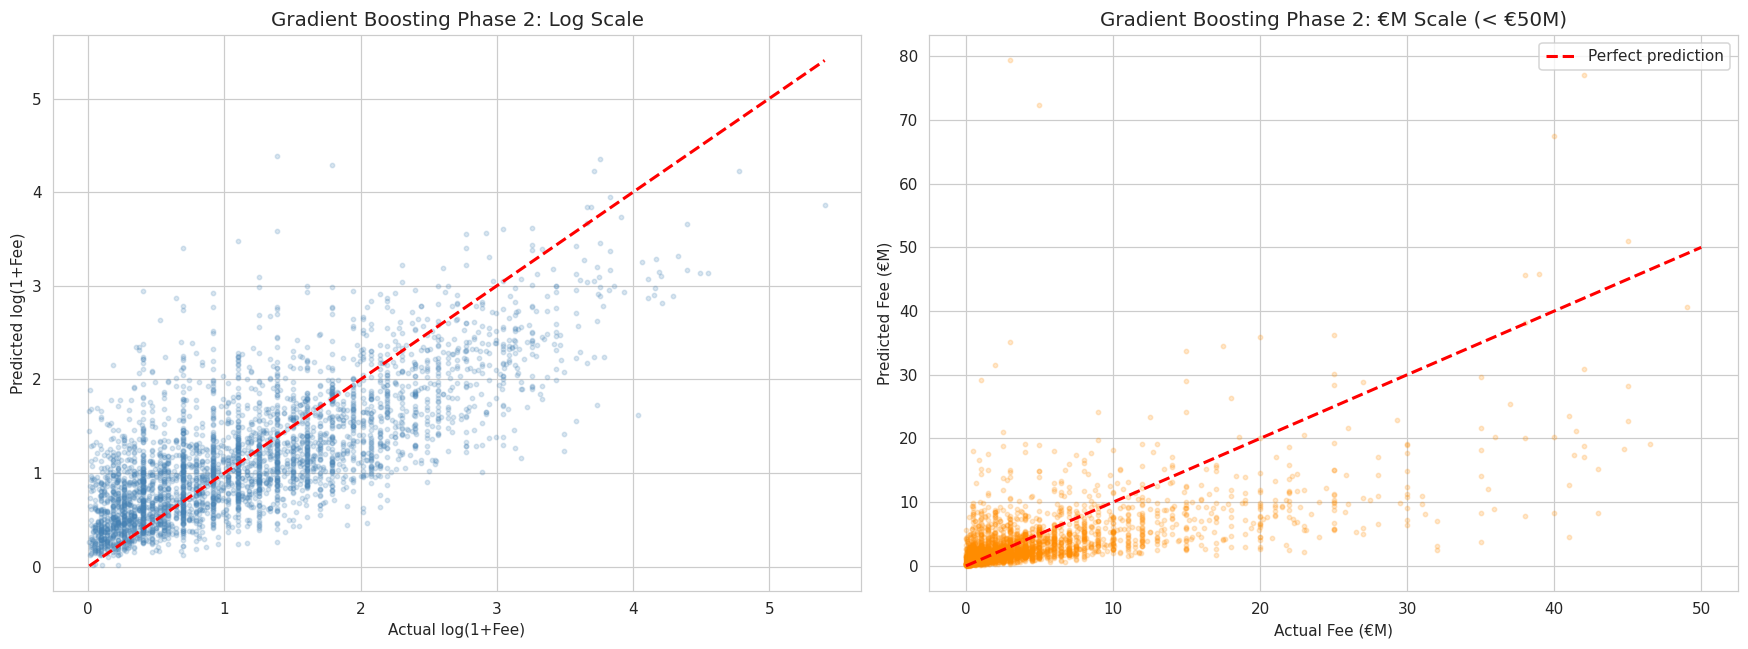

→ Model tracks the general trend well. Errors are larger for high-fee transfers (€30M+),
  which is expected since blockbuster deals depend heavily on unobservable factors.


In [49]:
# ═══ Actual vs Predicted in REAL €M (not log scale) ═══
best_p2_yp = [r['yp'] for r in results if 'Gradient Boosting' in r['name'] and 'Phase 2' in r['name']][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log scale
axes[0].scatter(y_te, best_p2_yp, alpha=0.2, s=8, color='steelblue')
axes[0].plot([y_te.min(),y_te.max()],[y_te.min(),y_te.max()],'r--',lw=2)
axes[0].set_xlabel('Actual log(1+Fee)'); axes[0].set_ylabel('Predicted log(1+Fee)')
axes[0].set_title('Gradient Boosting Phase 2: Log Scale', fontsize=13)

# €M scale (capped at €50M for visibility)
y_actual_m = np.expm1(y_te)
y_pred_m = np.expm1(best_p2_yp)
mask = y_actual_m < 50  # cap for visibility
axes[1].scatter(y_actual_m[mask], y_pred_m[mask], alpha=0.2, s=8, color='darkorange')
axes[1].plot([0, 50], [0, 50], 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Fee (€M)'); axes[1].set_ylabel('Predicted Fee (€M)')
axes[1].set_title('Gradient Boosting Phase 2: €M Scale (< €50M)', fontsize=13)
axes[1].legend()

plt.tight_layout(); plt.show()
print(f'→ Model tracks the general trend well. Errors are larger for high-fee transfers (€30M+),')
print(f'  which is expected since blockbuster deals depend heavily on unobservable factors.')

In [50]:
yto = np.expm1(y_te)
print("Real-World Error (€M) — Phase 2 Models:")
print("=" * 65)
for name, yp in p2_models:
    ypo = np.expm1(yp)
    mae_o = mean_absolute_error(yto, ypo)
    med_ae = np.median(np.abs(yto - ypo))
    print(f"  {name:25s} | MAE: €{mae_o:.2f}M | Median AE: €{med_ae:.2f}M")
print("=" * 65)

Real-World Error (€M) — Phase 2 Models:
  Ridge                     | MAE: €2.83M | Median AE: €1.12M
  Random Forest             | MAE: €2.72M | Median AE: €1.08M
  Gradient Boosting         | MAE: €2.71M | Median AE: €1.01M


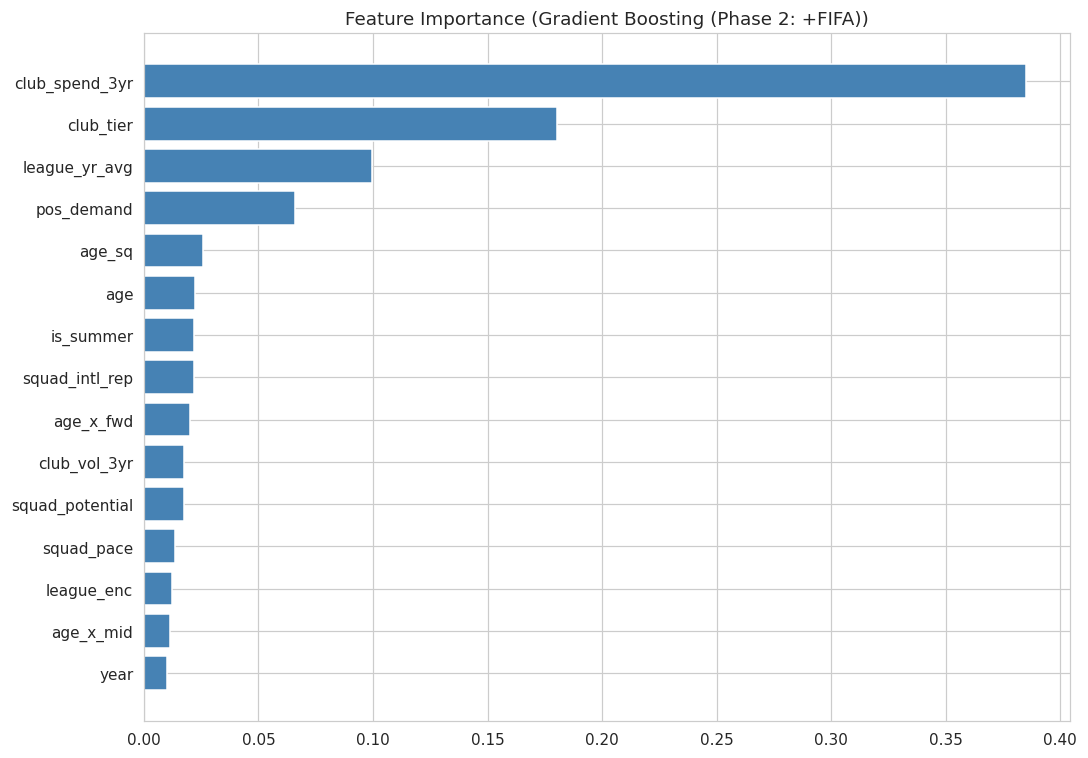

In [51]:
# Feature importance (best Phase 2 model)
best_p2 = [r for r in results if 'Phase 2' in r['name']]
best_p2 = max(best_p2, key=lambda x: x['r2'])
if hasattr(best_p2['pipe'].named_steps['m'], 'feature_importances_'):
    fi = pd.DataFrame({'Feature': phase2_features,
                       'Importance': best_p2['pipe'].named_steps['m'].feature_importances_})
    fi = fi.sort_values('Importance', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(fi['Feature'], fi['Importance'], color='steelblue')
    ax.set_title(f"Feature Importance ({best_p2['name']})"); ax.invert_yaxis()
    plt.tight_layout(); plt.show()

Player Prediction

In [53]:
def predict_and_recommend(age, position, preferred_league=None, top_n=10):
    """
    MODEL-POWERED PREDICTION: Given a player's age and position,
    uses the trained Gradient Boosting model to predict their transfer fee
    and recommends the best clubs to trial at.
    """
    # ── Validate inputs ──
    valid_positions = ['Goalkeeper','Centre-Back','Left-Back','Right-Back',
                       'Defensive Midfield','Central Midfield','Attacking Midfield',
                       'Left Midfield','Right Midfield','Left Winger','Right Winger',
                       'Centre-Forward','Second Striker']
    if position not in valid_positions:
        print(f"Invalid position. Choose from: {valid_positions}")
        return

    # ── Map position to group ──
    pos_grp_map = {
        'Goalkeeper':'Goalkeeper',
        'Centre-Back':'Defender','Left-Back':'Defender','Right-Back':'Defender',
        'Central Midfield':'Midfielder','Defensive Midfield':'Midfielder',
        'Attacking Midfield':'Midfielder','Left Midfield':'Midfielder','Right Midfield':'Midfielder',
        'Centre-Forward':'Forward','Second Striker':'Forward',
        'Left Winger':'Forward','Right Winger':'Forward'
    }
    pos_group = pos_grp_map[position]

    # ── Build feature vector using the LATEST year's market conditions ──
    latest_year = df['year'].max()  # 2022
    recent = df[df['year'] >= latest_year - 2]  # last 3 years of data

    # Get market-level values for the latest period
    market_infl = df[df['year']==latest_year]['market_infl'].median()
    league_yr = recent.groupby('league_name')['league_yr_avg'].median()
    pos_demand = recent[recent['position']==position]['pos_demand'].median()
    if pd.isna(pos_demand):
        pos_demand = recent['pos_demand'].median()

    # ── For EACH active club, predict what fee they'd pay for this player ──
    active_clubs = recent.groupby(['club_name','league_name']).agg(
        club_spend_3yr=('club_spend_3yr','median'),
        club_vol_3yr=('club_vol_3yr','median'),
        club_tier=('club_tier','median'),
        league_enc=('league_enc','median'),
        league_yr_avg=('league_yr_avg','median')
    ).reset_index()

    # Add FIFA features if available
    fifa_cols_available = [c for c in ['squad_overall','squad_potential','squad_intl_rep',
                                       'squad_pace','squad_shooting'] if c in recent.columns]
    if fifa_cols_available:
        fifa_agg = recent.groupby('club_name')[fifa_cols_available].median().reset_index()
        active_clubs = active_clubs.merge(fifa_agg, on='club_name', how='left')

    league_fifa_cols = [c for c in ['league_avg_overall','league_avg_potential','league_avg_intl_rep']
                        if c in recent.columns]
    if league_fifa_cols:
        lfifa_agg = recent.groupby('league_name')[league_fifa_cols].median().reset_index()
        active_clubs = active_clubs.merge(lfifa_agg, on='league_name', how='left')

    if preferred_league:
        active_clubs = active_clubs[active_clubs['league_name']==preferred_league]

    if len(active_clubs) == 0:
        print(f"No clubs found for league: {preferred_league}")
        return

    # ── Build prediction DataFrame for all clubs ──
    pred_rows = []
    for _, club_row in active_clubs.iterrows():
        row = {
            'age': age,
            'age_sq': age ** 2,
            'is_peak': 1 if 23 <= age <= 29 else 0,
            'year': latest_year,
            'is_summer': 1,  # assume summer window
            'market_infl': market_infl,
            'club_spend_3yr': club_row['club_spend_3yr'],
            'club_vol_3yr': club_row['club_vol_3yr'],
            'club_tier': club_row['club_tier'],
            'pos_demand': pos_demand,
            'league_yr_avg': club_row['league_yr_avg'],
            'league_enc': club_row['league_enc'],
            'is_cross_lg': 0,
            'age_x_fwd': age if pos_group == 'Forward' else 0,
            'age_x_mid': age if pos_group == 'Midfielder' else 0,
        }
        # Add position dummies
        for pc in pos_cols:
            pos_name = pc.replace('pos_', '')
            row[pc] = 1 if pos_name == position else 0

        # Add FIFA features
        for fc in fifa_cols_available:
            row[fc] = club_row.get(fc, df[fc].median() if fc in df.columns else 0)
        for lc in league_fifa_cols:
            row[lc] = club_row.get(lc, df[lc].median() if lc in df.columns else 0)

        pred_rows.append({
            'club_name': club_row['club_name'],
            'league_name': club_row['league_name'],
            **row
        })

    pred_df = pd.DataFrame(pred_rows)

    # ── Use the BEST trained model to predict ──
    # Determine which feature set to use based on what's available
    try:
        X_pred = pred_df[phase2_features].fillna(pred_df[phase2_features].median())
        best_model = [r for r in results if 'Gradient Boosting' in r['name'] and 'Phase 2' in r['name']][0]['pipe']
        model_used = 'Gradient Boosting (Phase 2)'
    except:
        X_pred = pred_df[phase1_features].fillna(pred_df[phase1_features].median())
        best_model = [r for r in results if 'Gradient Boosting' in r['name'] and 'Phase 1' in r['name']][0]['pipe']
        model_used = 'Gradient Boosting (Phase 1)'

    # Predict log fees, convert to €M
    pred_df['predicted_log_fee'] = best_model.predict(X_pred)
    pred_df['predicted_fee_EUR_M'] = np.expm1(pred_df['predicted_log_fee']).round(2)

    # ── Sort by predicted fee (clubs willing to pay more = more interested) ──
    pred_df = pred_df.sort_values('predicted_fee_EUR_M', ascending=False)

    # ── Also check which clubs HISTORICALLY sign this position + age ──
    hist_pos = recent[recent['position_group']==pos_group].groupby('club_name').size().reset_index(name='pos_signings')
    hist_age = recent[(recent['age']>=age-2)&(recent['age']<=age+2)].groupby('club_name').size().reset_index(name='age_signings')
    pred_df = pred_df.merge(hist_pos, on='club_name', how='left')
    pred_df = pred_df.merge(hist_age, on='club_name', how='left')
    pred_df['pos_signings'] = pred_df['pos_signings'].fillna(0).astype(int)
    pred_df['age_signings'] = pred_df['age_signings'].fillna(0).astype(int)
    pred_df['match_score'] = pred_df['pos_signings'] + pred_df['age_signings']

    # ── Combined ranking: predicted fee + historical match ──
    pred_df['fee_rank'] = pred_df['predicted_fee_EUR_M'].rank(ascending=False)
    pred_df['hist_rank'] = pred_df['match_score'].rank(ascending=False)
    pred_df['combined_rank'] = (pred_df['fee_rank'] + pred_df['hist_rank']).rank()
    pred_df = pred_df.sort_values('combined_rank')

    # ── Display results ──
    avg_fee = pred_df['predicted_fee_EUR_M'].median()

    print(f"{'='*75}")
    print(f"  MODEL PREDICTION — {position}, Age {age}")
    print(f"  Model: {model_used}")
    if preferred_league:
        print(f"  League: {preferred_league}")
    print(f"{'='*75}")
    print(f"\n  YOUR PREDICTED MARKET VALUE: €{avg_fee:.2f}M (median across all clubs)")
    print(f"  Range: €{pred_df['predicted_fee_EUR_M'].quantile(0.25):.2f}M – €{pred_df['predicted_fee_EUR_M'].quantile(0.75):.2f}M")

    print(f"\n  TOP {min(top_n, len(pred_df))} RECOMMENDED CLUBS (model prediction + historical fit):")
    print(f"  {'':3s} {'Club':30s} {'League':20s} {'Pred Fee':>10s} {'Pos Hist':>9s} {'Age Hist':>9s}")
    print(f"  {'-'*85}")

    for i, (_, row) in enumerate(pred_df.head(top_n).iterrows()):
        print(f"  {i+1:2d}. {row['club_name']:30s} {row['league_name']:20s} "
              f"€{row['predicted_fee_EUR_M']:>7.2f}M  {row['pos_signings']:>5d} sig  {row['age_signings']:>5d} sig")

    print(f"\n  {'='*75}")
    print(f"  INTERPRETATION:")
    print(f"  • 'Pred Fee' = What the model predicts this club would pay for your profile")
    print(f"  • 'Pos Hist' = How many {pos_group}s this club signed recently")
    print(f"  • 'Age Hist' = How many players aged {age-2}–{age+2} this club signed recently")
    print(f"  • Clubs ranked by COMBINED score (predicted willingness + historical pattern)")
    print(f"  {'='*75}")

    return pred_df[['club_name','league_name','predicted_fee_EUR_M','pos_signings','age_signings']].head(top_n)


In [54]:
# ═══ Example 1: 22-year-old Central Midfielder targeting Serie A ═══
predict_and_recommend(age=22, position='Central Midfield', preferred_league='Serie A')

  MODEL PREDICTION — Central Midfield, Age 22
  Model: Gradient Boosting (Phase 2)
  League: Serie A

  YOUR PREDICTED MARKET VALUE: €3.75M (median across all clubs)
  Range: €2.15M – €5.43M

  TOP 10 RECOMMENDED CLUBS (model prediction + historical fit):
      Club                           League                 Pred Fee  Pos Hist  Age Hist
  -------------------------------------------------------------------------------------
   1. AC Milan                       Serie A              €   7.65M      9 sig     16 sig
   2. Juventus FC                    Serie A              €  19.15M      8 sig     11 sig
   3. US Sassuolo                    Serie A              €   4.92M      7 sig     19 sig
   4. Atalanta BC                    Serie A              €   5.44M      6 sig     15 sig
   5. AS Roma                        Serie A              €   9.92M      4 sig     10 sig
   6. ACF Fiorentina                 Serie A              €   6.43M      7 sig     10 sig
   7. Inter Milan          

,club_name,league_name,predicted_fee_EUR_M,pos_signings,age_signings
4,AC Milan,Serie A,7.65,9,16
0,Juventus FC,Serie A,19.15,8,11
8,US Sassuolo,Serie A,4.92,7,19
6,Atalanta BC,Serie A,5.44,6,15
2,AS Roma,Serie A,9.92,4,10
5,ACF Fiorentina,Serie A,6.43,7,10
1,Inter Milan,Serie A,15.21,5,6
11,Genoa CFC,Serie A,4.08,7,15
7,SS Lazio,Serie A,5.41,6,8
3,SSC Napoli,Serie A,8.71,4,7


In [55]:
# ═══ Example 2: 23-year-old Centre-Forward, all leagues ═══
predict_and_recommend(age=23, position='Centre-Forward')

  MODEL PREDICTION — Centre-Forward, Age 23
  Model: Gradient Boosting (Phase 2)

  YOUR PREDICTED MARKET VALUE: €3.09M (median across all clubs)
  Range: €1.47M – €7.57M

  TOP 10 RECOMMENDED CLUBS (model prediction + historical fit):
      Club                           League                 Pred Fee  Pos Hist  Age Hist
  -------------------------------------------------------------------------------------
   1. Tottenham Hotspur              Premier League       €  24.95M      5 sig     14 sig
   2. Chelsea FC                     Premier League       €  27.56M      8 sig     10 sig
   3. Nottingham Forest              Premier League       €  12.64M      6 sig     17 sig
   4. Wolverhampton Wanderers        Premier League       €  21.12M      9 sig      9 sig
   5. Leeds United                   Premier League       €  12.32M      9 sig     12 sig
   6. Juventus FC                    Serie A              €  14.07M      7 sig     13 sig
   7. Arsenal FC                     Premier Le

,club_name,league_name,predicted_fee_EUR_M,pos_signings,age_signings
3,Tottenham Hotspur,Premier League,24.95,5,14
1,Chelsea FC,Premier League,27.56,8,10
26,Nottingham Forest,Premier League,12.64,6,17
10,Wolverhampton Wanderers,Premier League,21.12,9,9
27,Leeds United,Premier League,12.32,9,12
23,Juventus FC,Serie A,14.07,7,13
9,Arsenal FC,Premier League,21.78,3,14
41,SL Benfica,Liga Nos,9.31,11,14
8,AS Monaco,Ligue 1,22.12,6,9
15,West Ham United,Premier League,17.93,5,11


In [56]:
# ═══ Example 3: 21-year-old Left-Back targeting Championship (lower league!) ═══
predict_and_recommend(age=21, position='Left-Back', preferred_league='Championship')

  MODEL PREDICTION — Left-Back, Age 21
  Model: Gradient Boosting (Phase 2)
  League: Championship

  YOUR PREDICTED MARKET VALUE: €1.16M (median across all clubs)
  Range: €0.74M – €2.00M

  TOP 10 RECOMMENDED CLUBS (model prediction + historical fit):
      Club                           League                 Pred Fee  Pos Hist  Age Hist
  -------------------------------------------------------------------------------------
   1. Watford FC                     Championship         €   3.60M      6 sig      8 sig
   2. Fulham FC                      Championship         €   3.13M      8 sig      5 sig
   3. AFC Bournemouth                Championship         €   5.29M      4 sig      5 sig
   4. Sheffield United               Championship         €   3.16M      3 sig      7 sig
   5. Burnley FC                     Championship         €   2.12M      5 sig      8 sig
   6. Brentford FC                   Championship         €   2.52M      3 sig      8 sig
   7. Nottingham Forest      

,club_name,league_name,predicted_fee_EUR_M,pos_signings,age_signings
1,Watford FC,Championship,3.60,6,8
3,Fulham FC,Championship,3.13,8,5
0,AFC Bournemouth,Championship,5.29,4,5
2,Sheffield United,Championship,3.16,3,7
5,Burnley FC,Championship,2.12,5,8
4,Brentford FC,Championship,2.52,3,8
11,Nottingham Forest,Championship,1.63,13,12
13,Norwich City,Championship,1.52,6,8
7,Sunderland AFC,Championship,2.04,2,4
6,Middlesbrough FC,Championship,2.09,1,4
